<a href="https://colab.research.google.com/github/Dakshgupta25/CarbonWise/blob/main/notebooks/carbonwise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Dakshgupta25/CarbonWise.git
%cd CarbonWise

Cloning into 'CarbonWise'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 27 (delta 8), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 2.39 MiB | 13.08 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/CarbonWise


In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel("data/Carbon Emission.xlsx")
df.head()

,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


**Data** **Cleaning**

In [4]:
print("Shape:")
print(df.shape)
print()
print("-----------------------------------------------------------------------------------")
print()
print("Columns:")
print(df.columns)
print()
print("-----------------------------------------------------------------------------------")
print()
print("Data Types:")
print(df.dtypes)
print()
print("-----------------------------------------------------------------------------------")
print()
print("Duplicated:")
print(df.duplicated().sum())


Shape:
(10000, 20)

-----------------------------------------------------------------------------------

Columns:
Index(['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source',
       'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill',
       'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km',
       'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour',
       'How Many New Clothes Monthly', 'How Long Internet Daily Hour',
       'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission'],
      dtype='object')

-----------------------------------------------------------------------------------

Data Types:
Body Type                        object
Sex                              object
Diet                             object
How Often Shower                 object
Heating Energy Source            object
Transport                        object
Vehicle Type                     object
Social Activity              

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   3279 non-null   object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         10000 non-null  int64 
 13  Ho

In [6]:
df.columns = df.columns.str.replace(' ', '_')
cat_col=df.columns[df.dtypes==object]
print("categorical_col:")
print(cat_col)
print()
print("-----------------------------------------------------------------------------------")
print()
num_col=df.columns[df.dtypes!=object]
print("numerical_col:")
print(num_col)

categorical_col:
Index(['Body_Type', 'Sex', 'Diet', 'How_Often_Shower', 'Heating_Energy_Source',
       'Transport', 'Vehicle_Type', 'Social_Activity',
       'Frequency_of_Traveling_by_Air', 'Waste_Bag_Size', 'Energy_efficiency',
       'Recycling', 'Cooking_With'],
      dtype='object')

-----------------------------------------------------------------------------------

numerical_col:
Index(['Monthly_Grocery_Bill', 'Vehicle_Monthly_Distance_Km',
       'Waste_Bag_Weekly_Count', 'How_Long_TV_PC_Daily_Hour',
       'How_Many_New_Clothes_Monthly', 'How_Long_Internet_Daily_Hour',
       'CarbonEmission'],
      dtype='object')


  **Missing values check**

In [7]:
print("Numerical_col null count:")
print(df[num_col].isnull().sum())
print()
print("-----------------------------------------------------------------------------------")
print()
print("Categorical_col null count:")
print(df[cat_col].isnull().sum())

Numerical_col null count:
Monthly_Grocery_Bill            0
Vehicle_Monthly_Distance_Km     0
Waste_Bag_Weekly_Count          0
How_Long_TV_PC_Daily_Hour       0
How_Many_New_Clothes_Monthly    0
How_Long_Internet_Daily_Hour    0
CarbonEmission                  0
dtype: int64

-----------------------------------------------------------------------------------

Categorical_col null count:
Body_Type                           0
Sex                                 0
Diet                                0
How_Often_Shower                    0
Heating_Energy_Source               0
Transport                           0
Vehicle_Type                     6721
Social_Activity                     0
Frequency_of_Traveling_by_Air       0
Waste_Bag_Size                      0
Energy_efficiency                   0
Recycling                           0
Cooking_With                        0
dtype: int64


In [8]:
df['Vehicle_Type'] = df.apply(
    lambda row: 'No Vehicle'
    if pd.isnull(row['Vehicle_Type']) and row['Transport'] in ['public', 'walk/bicycle']
    else row['Vehicle_Type'],
    axis=1
)

In [9]:
df[cat_col].isnull().sum()

,0
Body_Type,0
Sex,0
Diet,0
How_Often_Shower,0
Heating_Energy_Source,0
Transport,0
Vehicle_Type,0
Social_Activity,0
Frequency_of_Traveling_by_Air,0
Waste_Bag_Size,0


**Categorical data Analysis**

In [10]:
for col in cat_col:
    print(f"\n--- {col} (%) ---")
    print((df[col].value_counts(normalize=True) * 100).round(2))


--- Body_Type (%) ---
Body_Type
underweight    25.40
obese          25.00
overweight     24.87
normal         24.73
Name: proportion, dtype: float64

--- Sex (%) ---
Sex
female    50.07
male      49.93
Name: proportion, dtype: float64

--- Diet (%) ---
Diet
pescatarian    25.54
vegan          24.97
omnivore       24.92
vegetarian     24.57
Name: proportion, dtype: float64

--- How_Often_Shower (%) ---
How_Often_Shower
daily              25.46
twice a day        25.16
less frequently    24.87
more frequently    24.51
Name: proportion, dtype: float64

--- Heating_Energy_Source (%) ---
Heating_Energy_Source
electricity    25.52
coal           25.23
wood           24.63
natural gas    24.62
Name: proportion, dtype: float64

--- Transport (%) ---
Transport
walk/bicycle    34.27
public          32.94
private         32.79
Name: proportion, dtype: float64

--- Vehicle_Type (%) ---
Vehicle_Type
No Vehicle    67.21
lpg            6.97
electric       6.71
petrol         6.47
hybrid         6.42

In [11]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Body_Type: 4 unique values
Sex: 2 unique values
Diet: 4 unique values
How_Often_Shower: 4 unique values
Heating_Energy_Source: 4 unique values
Transport: 3 unique values
Vehicle_Type: 6 unique values
Social_Activity: 3 unique values
Frequency_of_Traveling_by_Air: 4 unique values
Waste_Bag_Size: 4 unique values
Energy_efficiency: 3 unique values
Recycling: 16 unique values
Cooking_With: 16 unique values


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


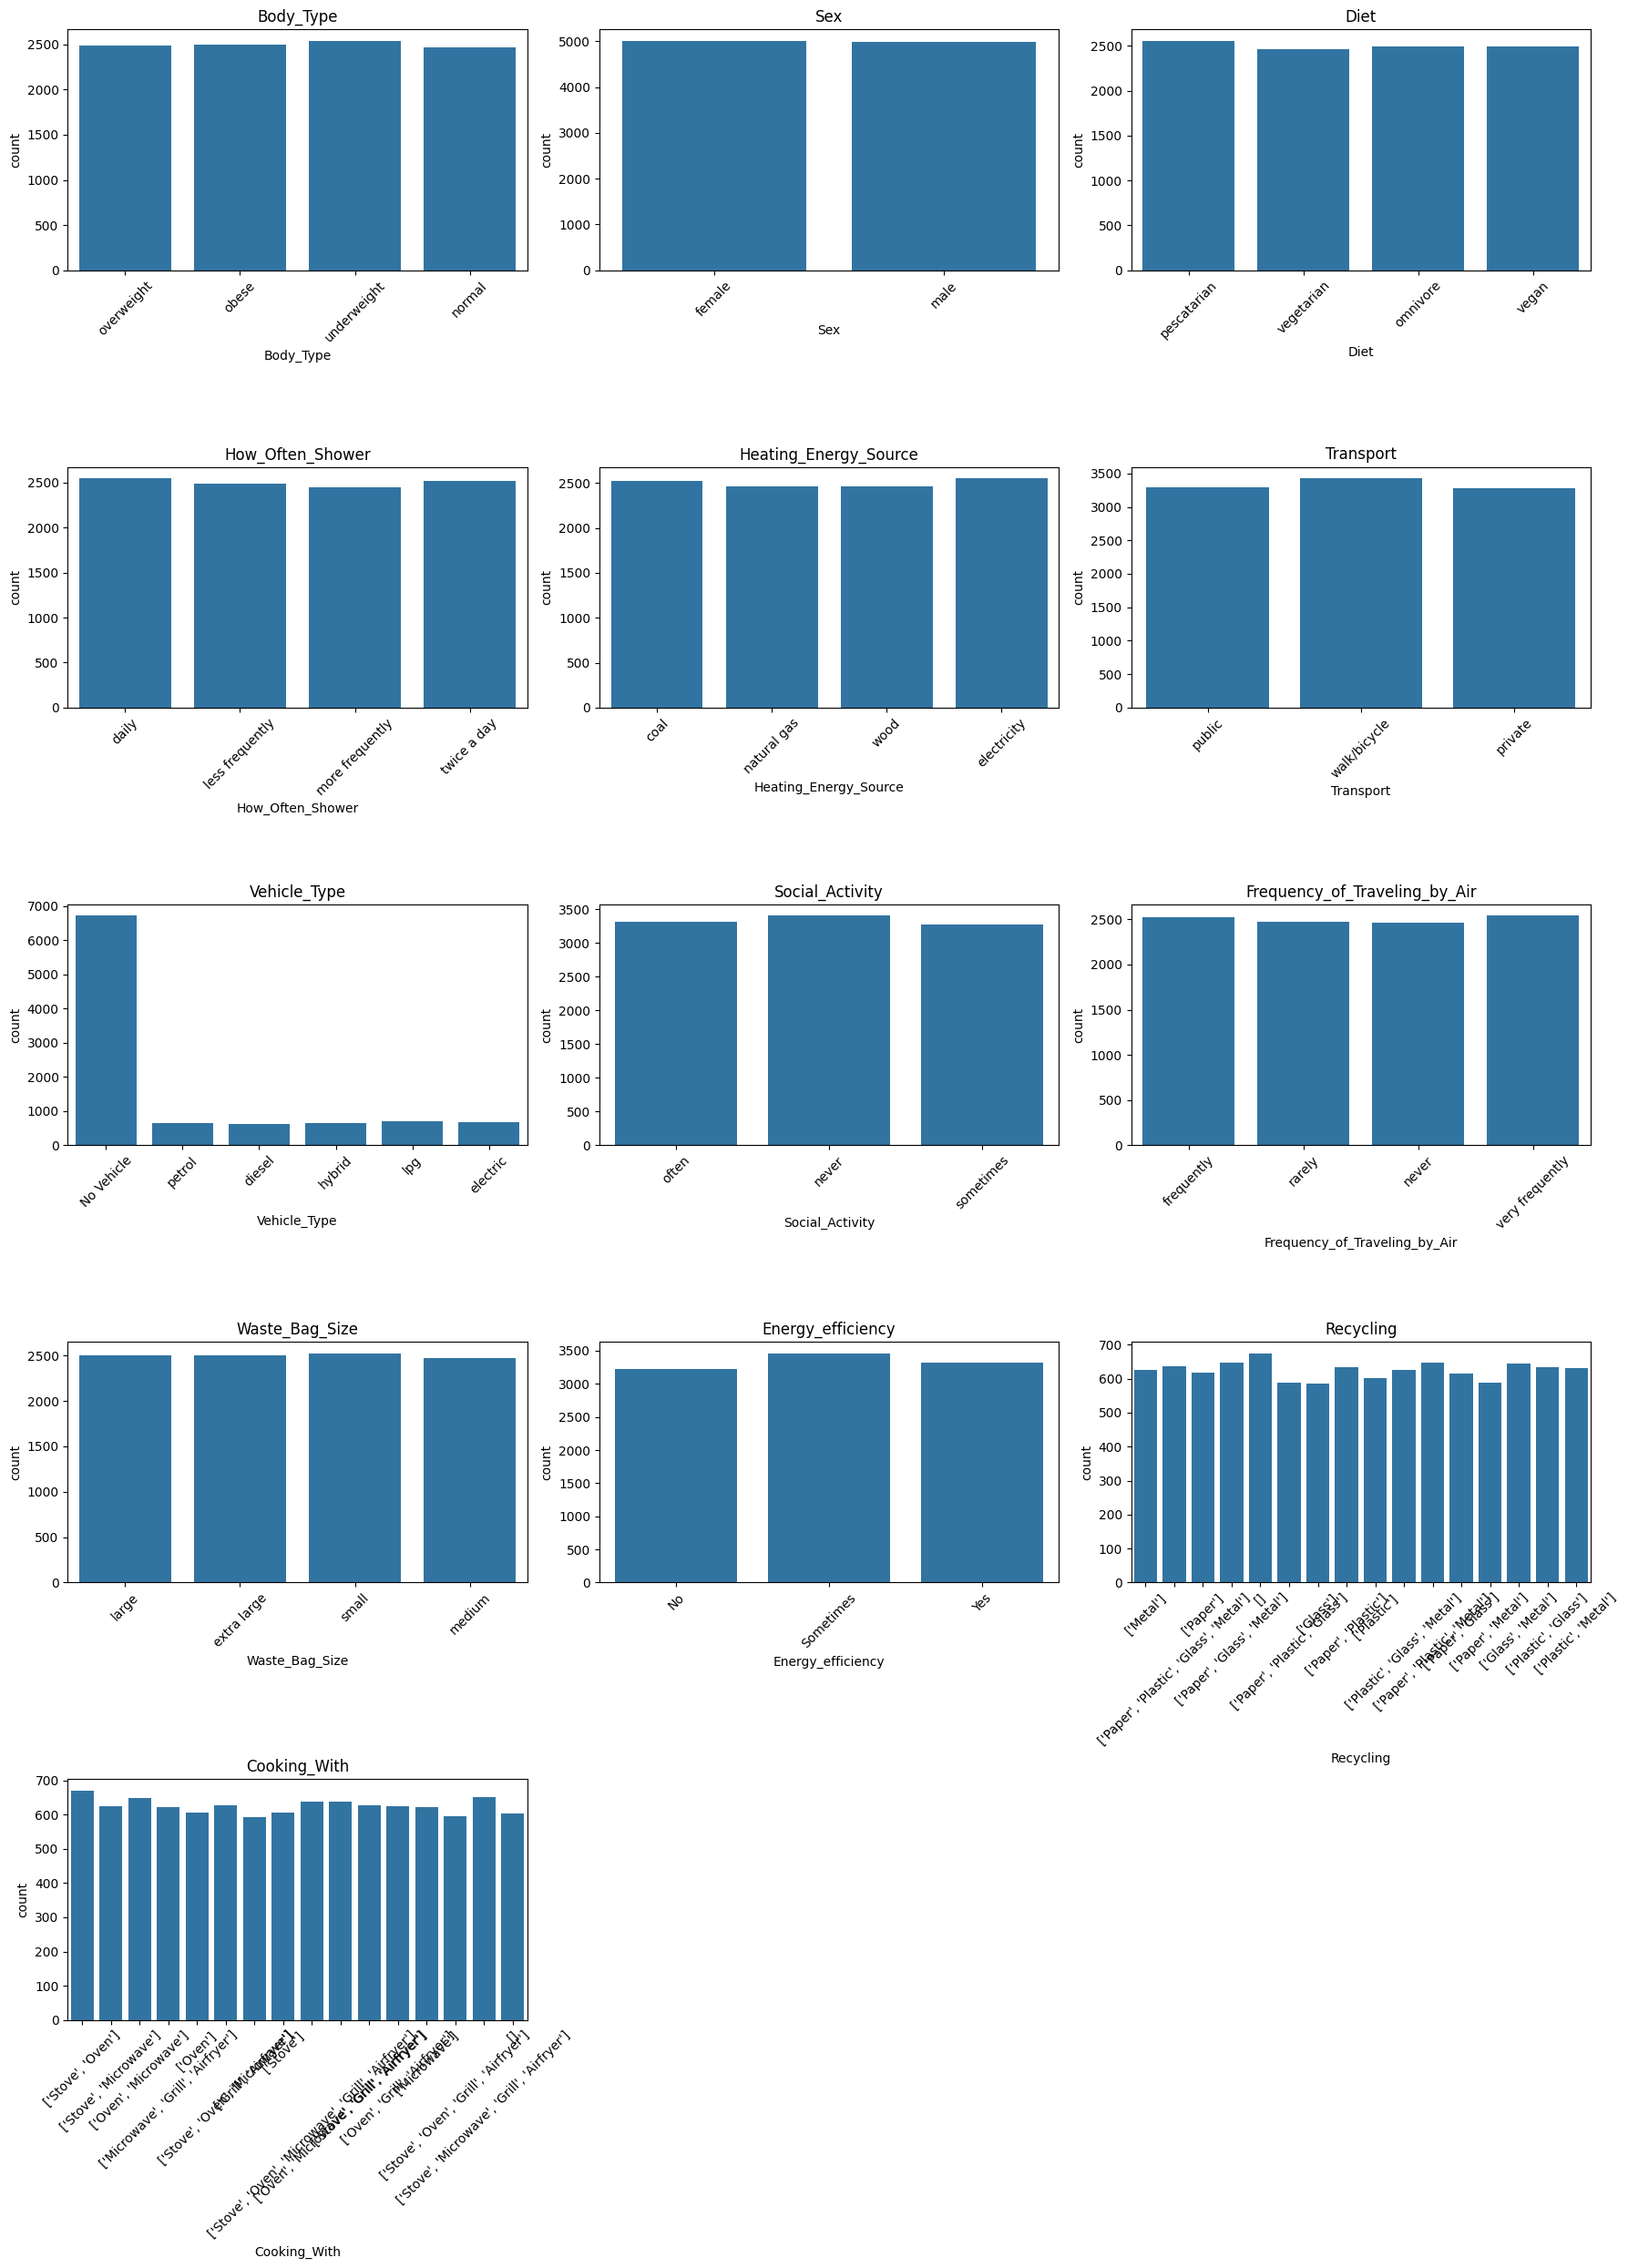

In [13]:
cols = 3
rows = (len(cat_col) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cat_col, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

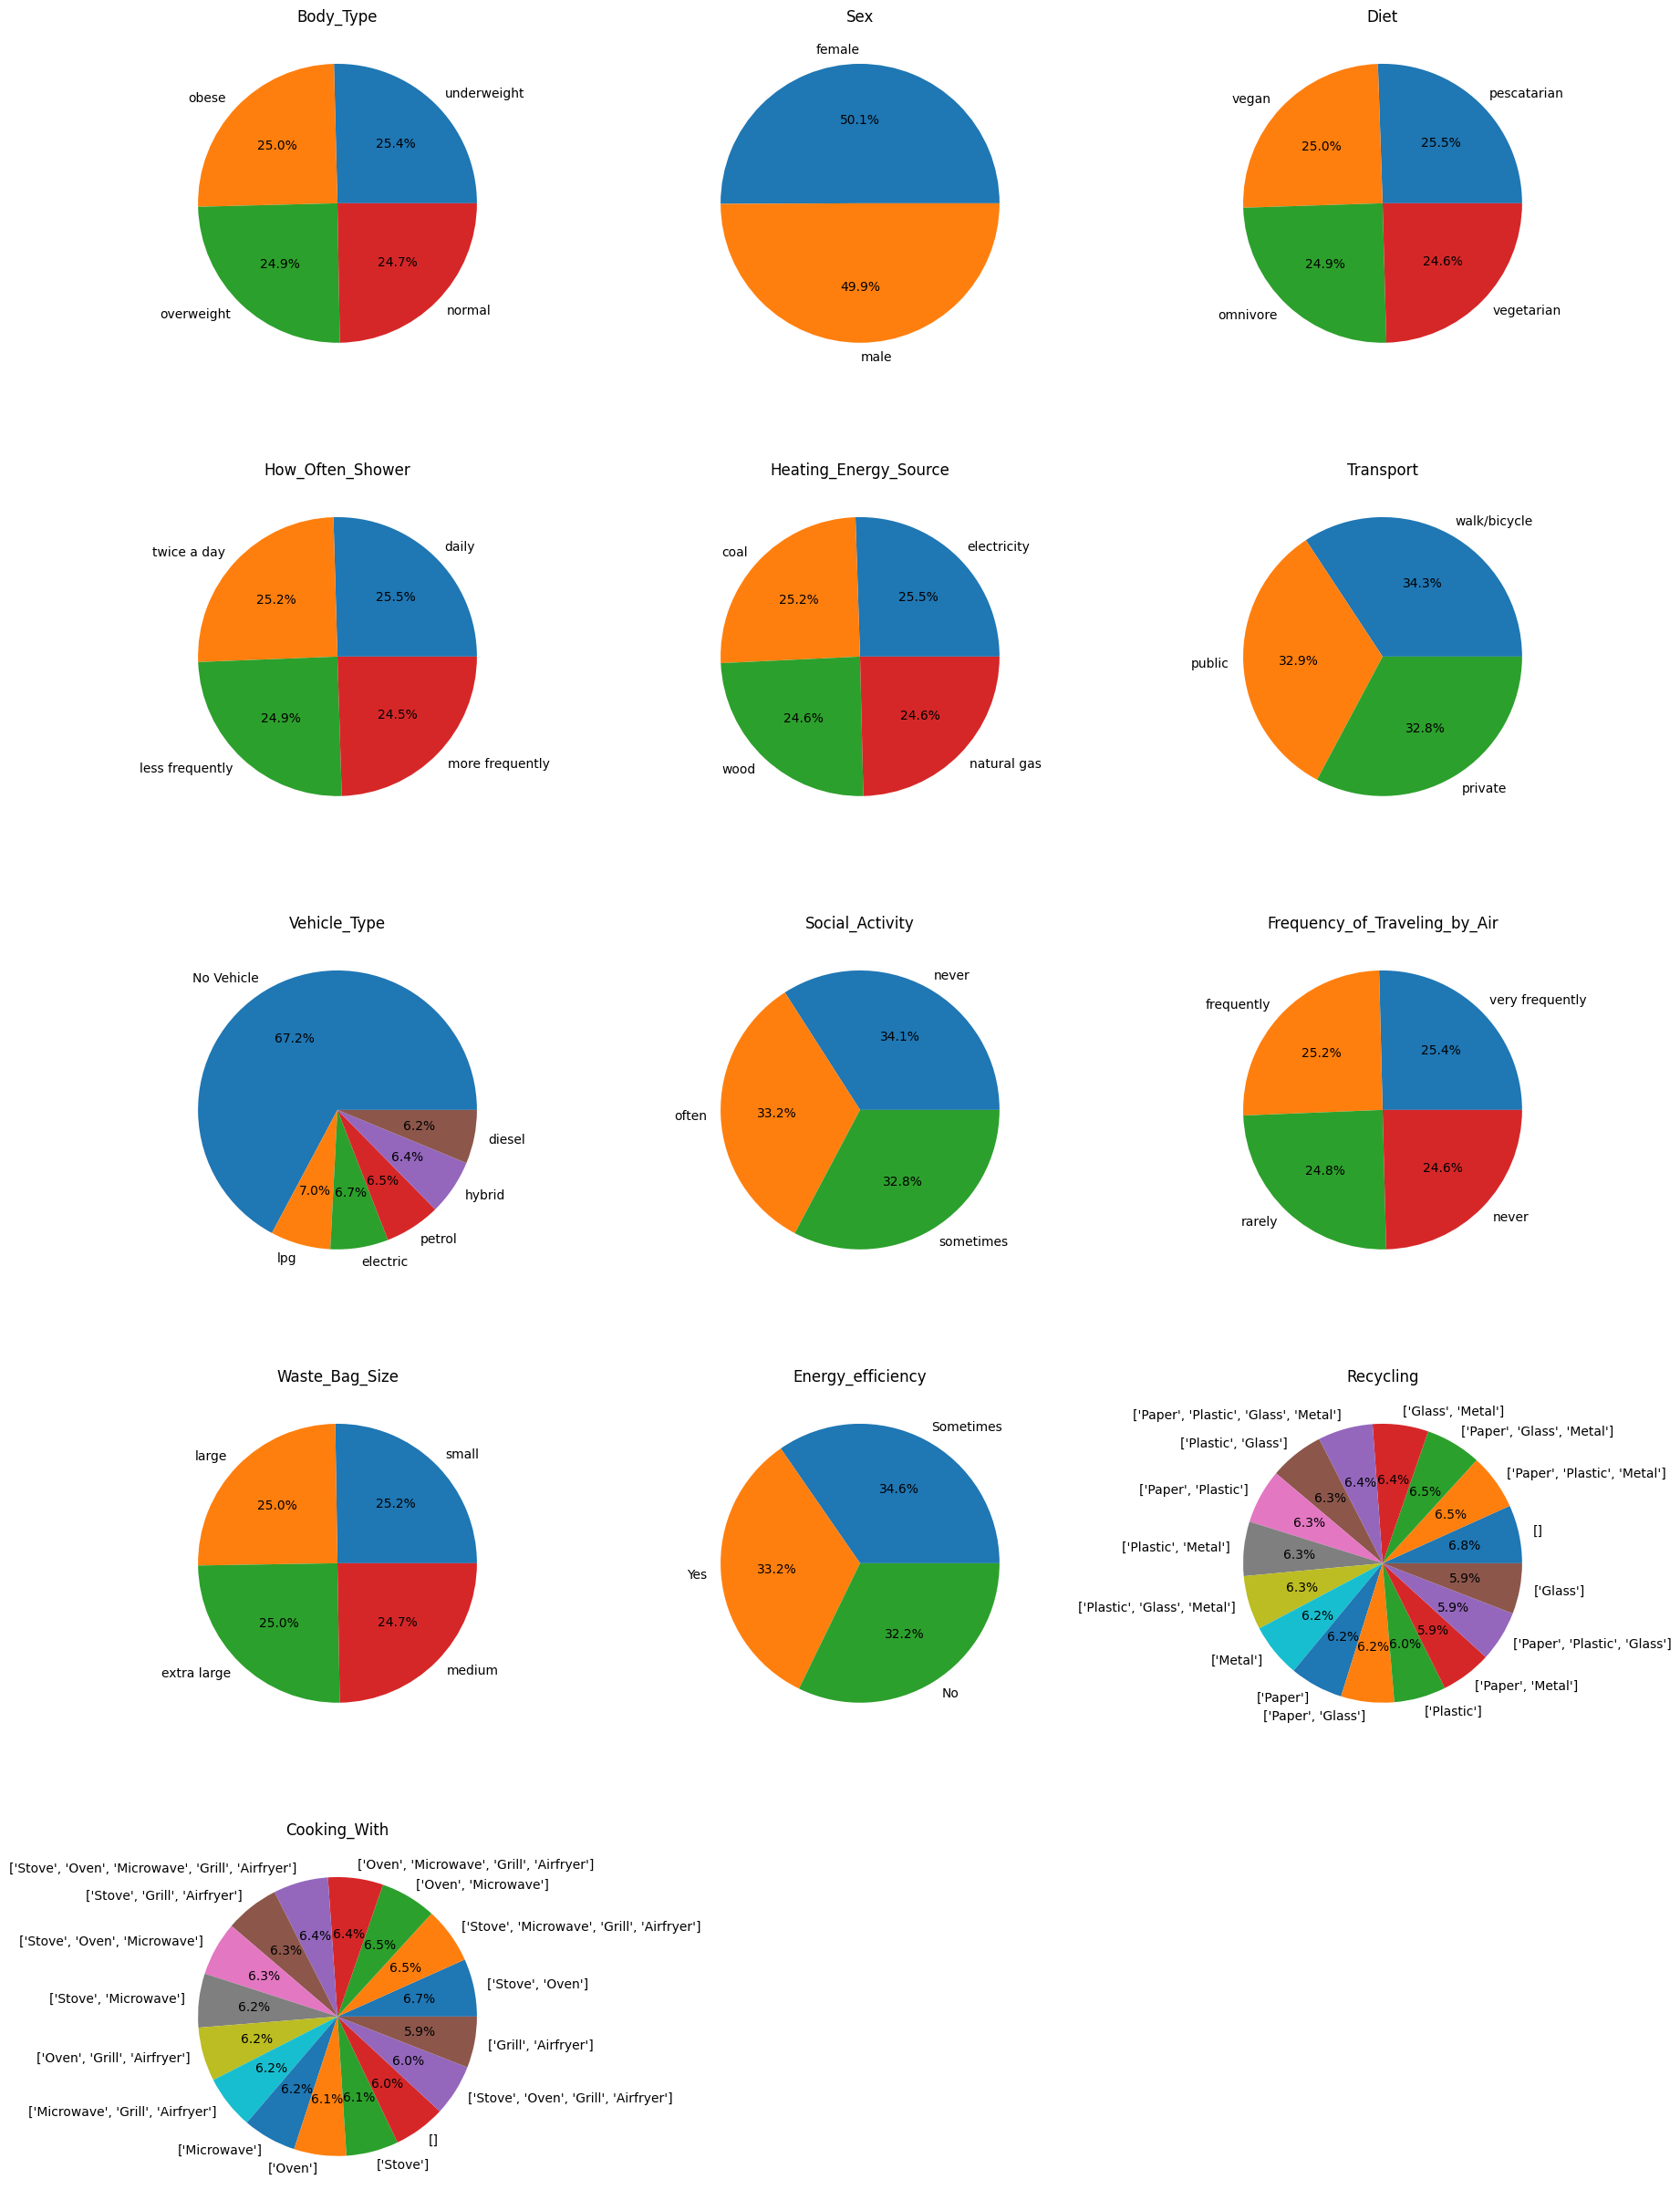

In [14]:

cols = 3
rows = (len(cat_col) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cat_col, 1):
    plt.subplot(rows, cols, i)
    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


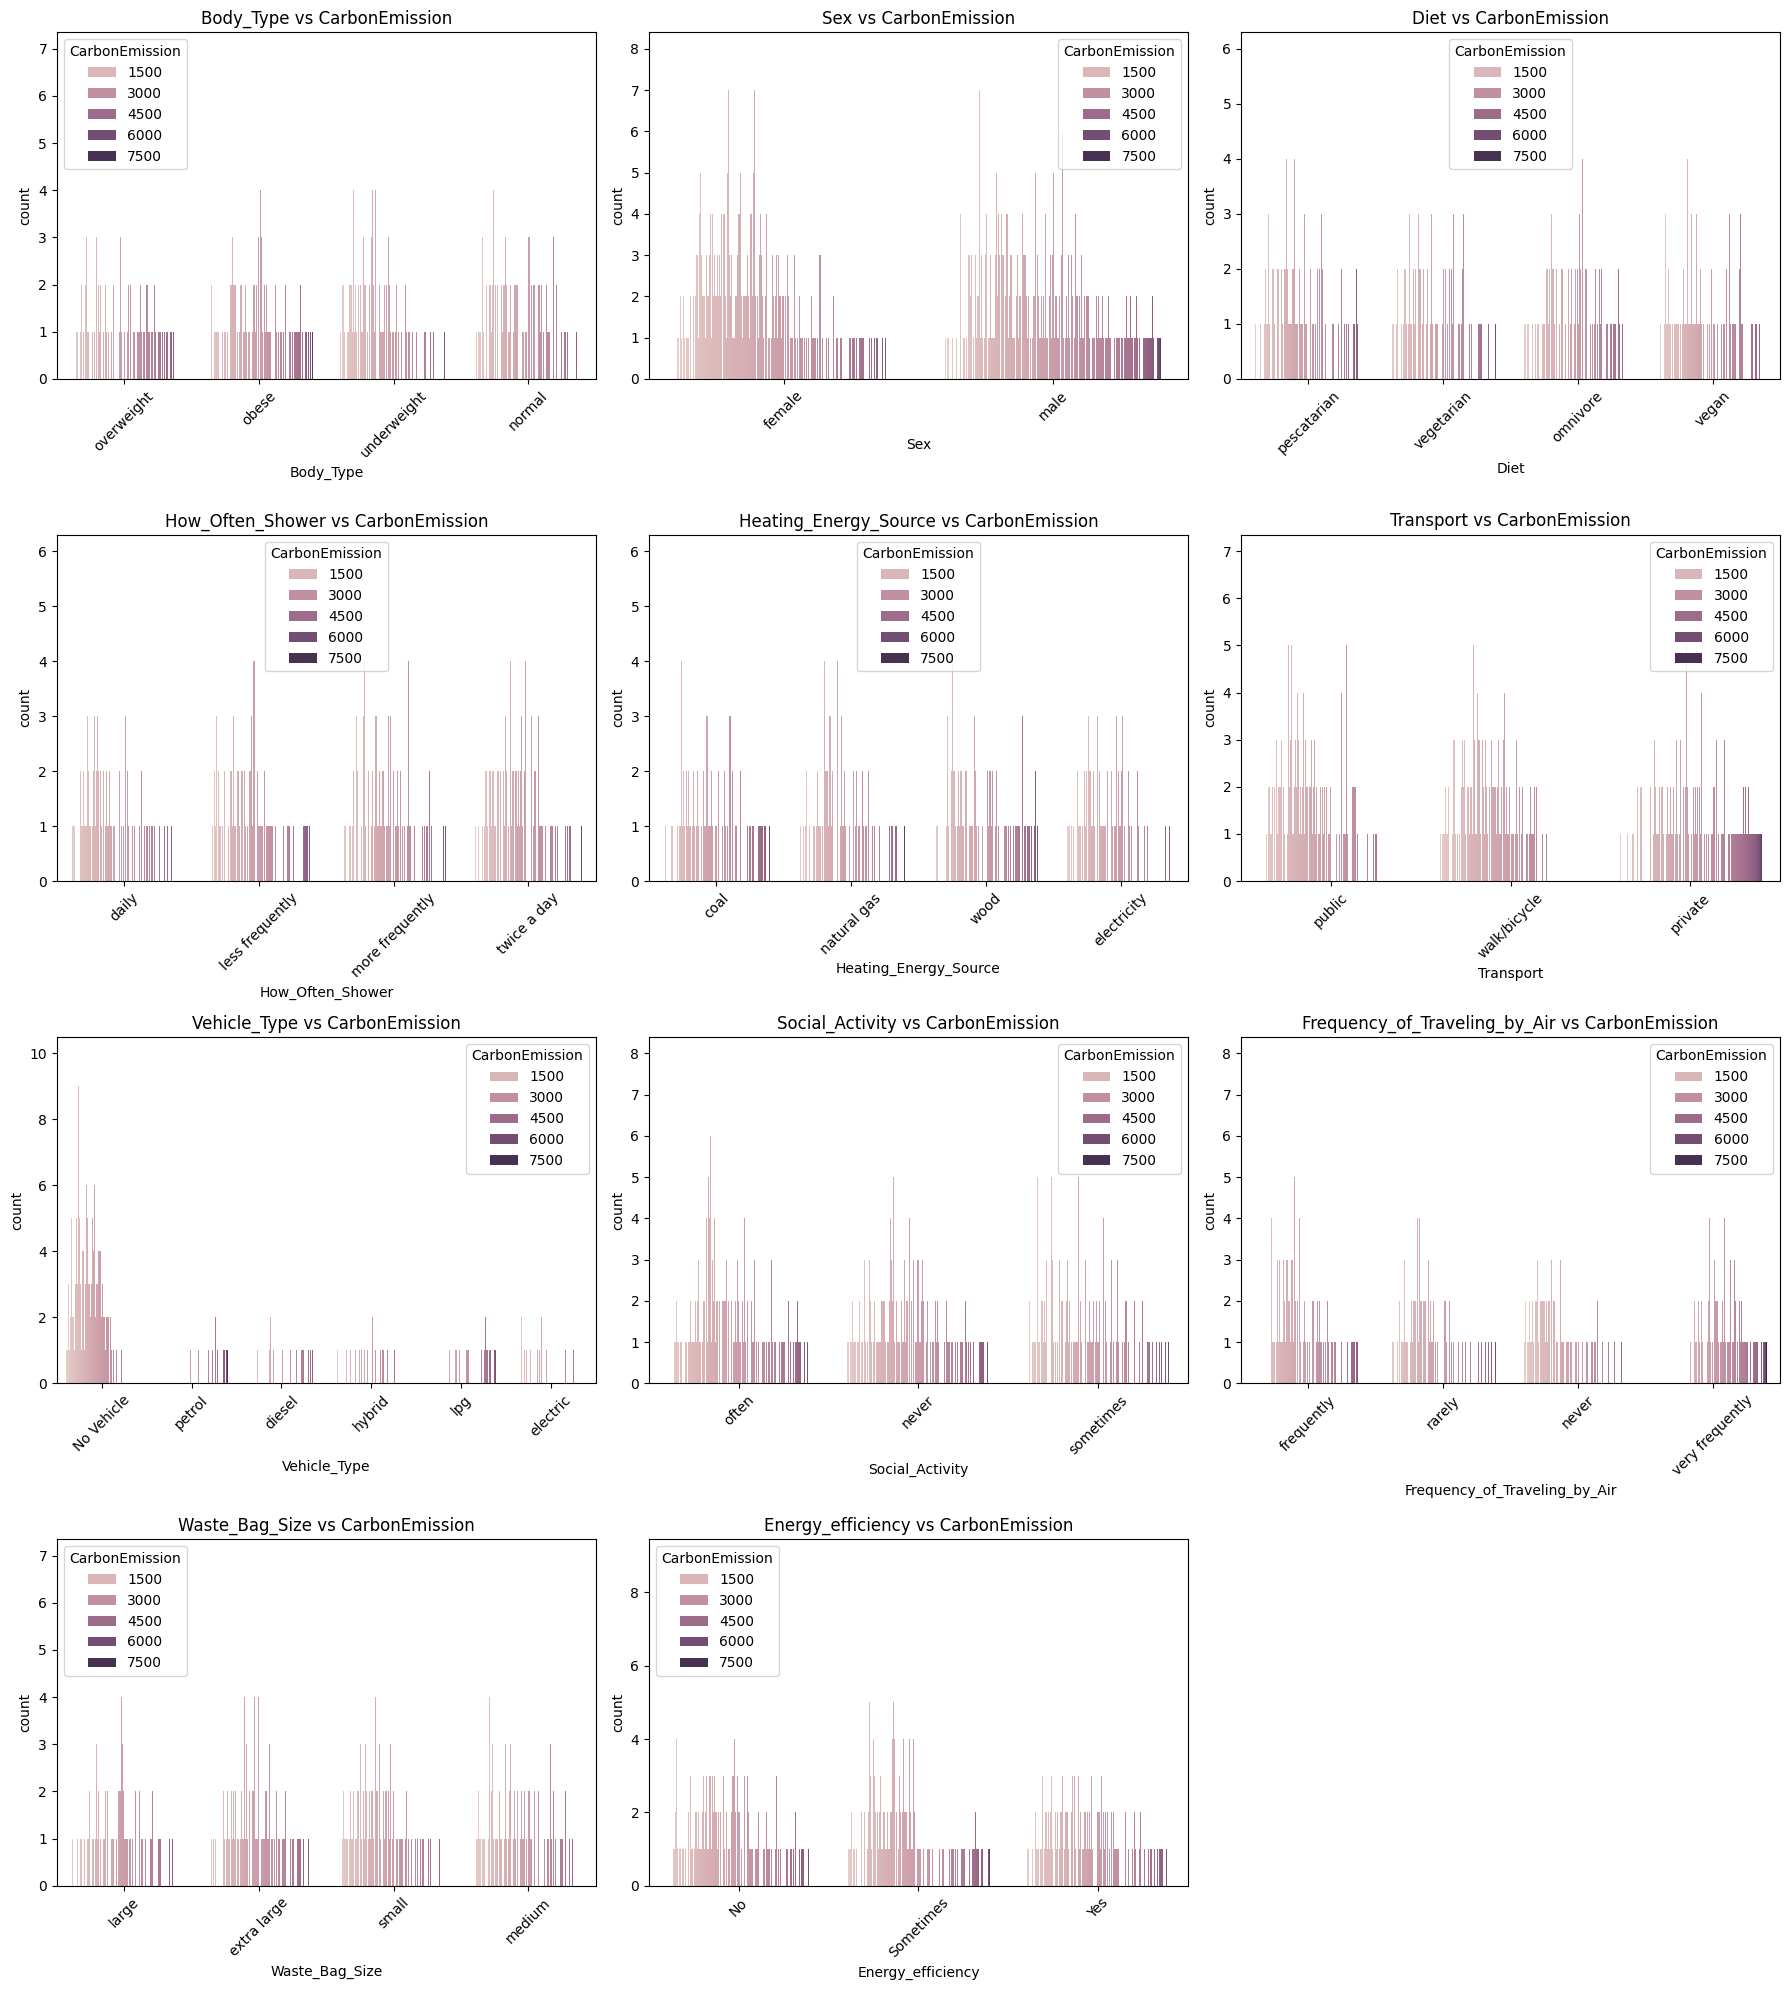

In [15]:
cat_col_filtered = [col for col in cat_col if df[col].nunique() <= 10]

cols = 3
rows = (len(cat_col_filtered) // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_col_filtered):
    sns.countplot(x=col, hue='CarbonEmission', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs CarbonEmission")
    axes[i].tick_params(axis='x', rotation=45)

# remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Numerical Col Analysis**

In [16]:
# Separate numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ❗ Remove target column from treatment
target = 'CarbonEmission'
if target in num_cols:
    num_cols.remove(target)

In [17]:
stats_df = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std': df[num_cols].std(),
    'skewness': df[num_cols].skew(),
    'min': df[num_cols].min(),
    'max': df[num_cols].max()
})

print(stats_df)

                                   mean  median          std  skewness  min  \
Monthly_Grocery_Bill           173.8752   173.0    72.234018  0.002999   50   
Vehicle_Monthly_Distance_Km   2031.4859   823.0  2769.715597  1.482282    0   
Waste_Bag_Weekly_Count           4.0246     4.0     1.990375 -0.013720    1   
How_Long_TV_PC_Daily_Hour       12.1392    12.0     7.106369 -0.032953    0   
How_Many_New_Clothes_Monthly    25.1090    25.0    14.698725 -0.014404    0   
How_Long_Internet_Daily_Hour    11.8891    12.0     7.277218  0.019689    0   

                               max  
Monthly_Grocery_Bill           299  
Vehicle_Monthly_Distance_Km   9999  
Waste_Bag_Weekly_Count           7  
How_Long_TV_PC_Daily_Hour       24  
How_Many_New_Clothes_Monthly    50  
How_Long_Internet_Daily_Hour    24  


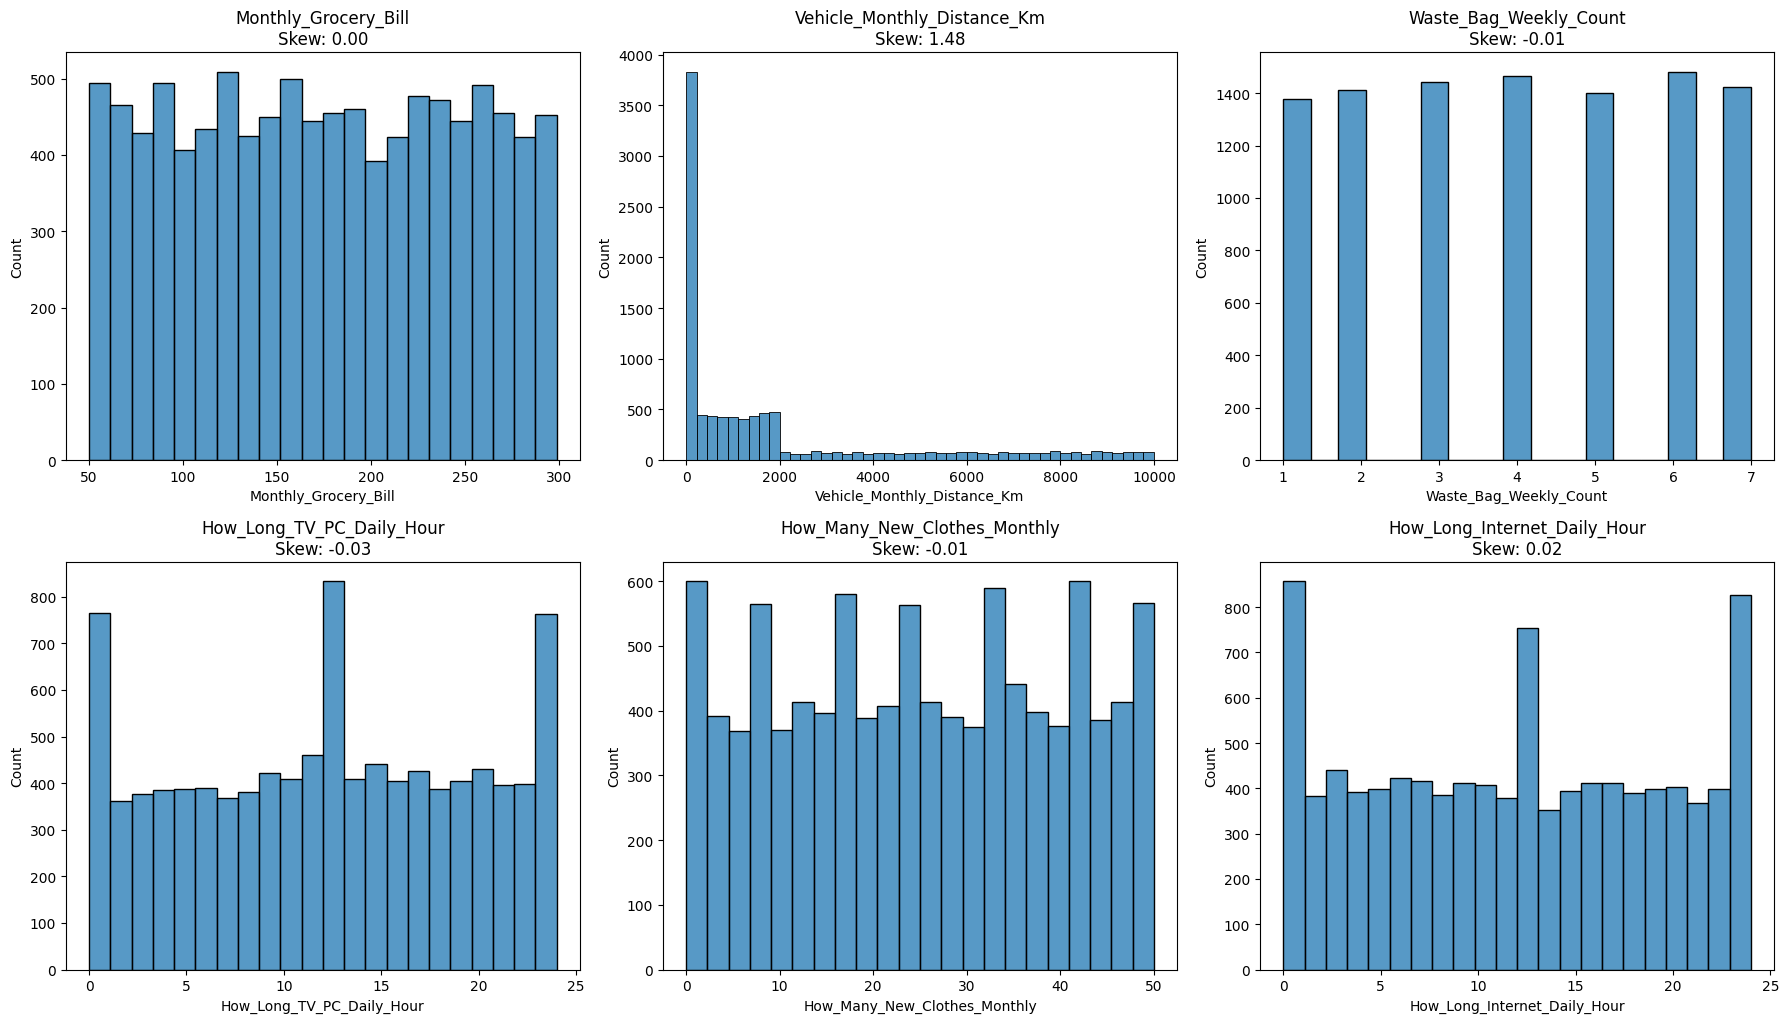

In [18]:
cols = 3
rows = (len(num_cols) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=False)
    plt.title(f"{col}\nSkew: {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

In [19]:
outlier_info = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    percent = (count / len(df)) * 100

    outlier_info.append([col, count, percent])

outlier_df = pd.DataFrame(outlier_info, columns=['Column', 'Outliers', 'Percent'])
print(outlier_df)

                         Column  Outliers  Percent
0          Monthly_Grocery_Bill         0     0.00
1   Vehicle_Monthly_Distance_Km      1294    12.94
2        Waste_Bag_Weekly_Count         0     0.00
3     How_Long_TV_PC_Daily_Hour         0     0.00
4  How_Many_New_Clothes_Monthly         0     0.00
5  How_Long_Internet_Daily_Hour         0     0.00


In [20]:
df_clean = df.copy()

skewed_cols = df[num_cols].skew().abs()

for col in num_cols:

    # 🔹 Step 1: Log transform for heavy skew
    if skewed_cols[col] > 1:
        df_clean[col] = np.log1p(df_clean[col])

    # 🔹 Step 2: Capping (NOT median replacement)
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = np.clip(df_clean[col], lower, upper)

In [21]:
outlier_check = []

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    outlier_check.append([col, count])

outlier_check_df = pd.DataFrame(outlier_check, columns=['Column', 'Remaining Outliers'])
print(outlier_check_df)

                         Column  Remaining Outliers
0          Monthly_Grocery_Bill                   0
1   Vehicle_Monthly_Distance_Km                   0
2        Waste_Bag_Weekly_Count                   0
3     How_Long_TV_PC_Daily_Hour                   0
4  How_Many_New_Clothes_Monthly                   0
5  How_Long_Internet_Daily_Hour                   0


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[num_cols]),
    columns=num_cols
)

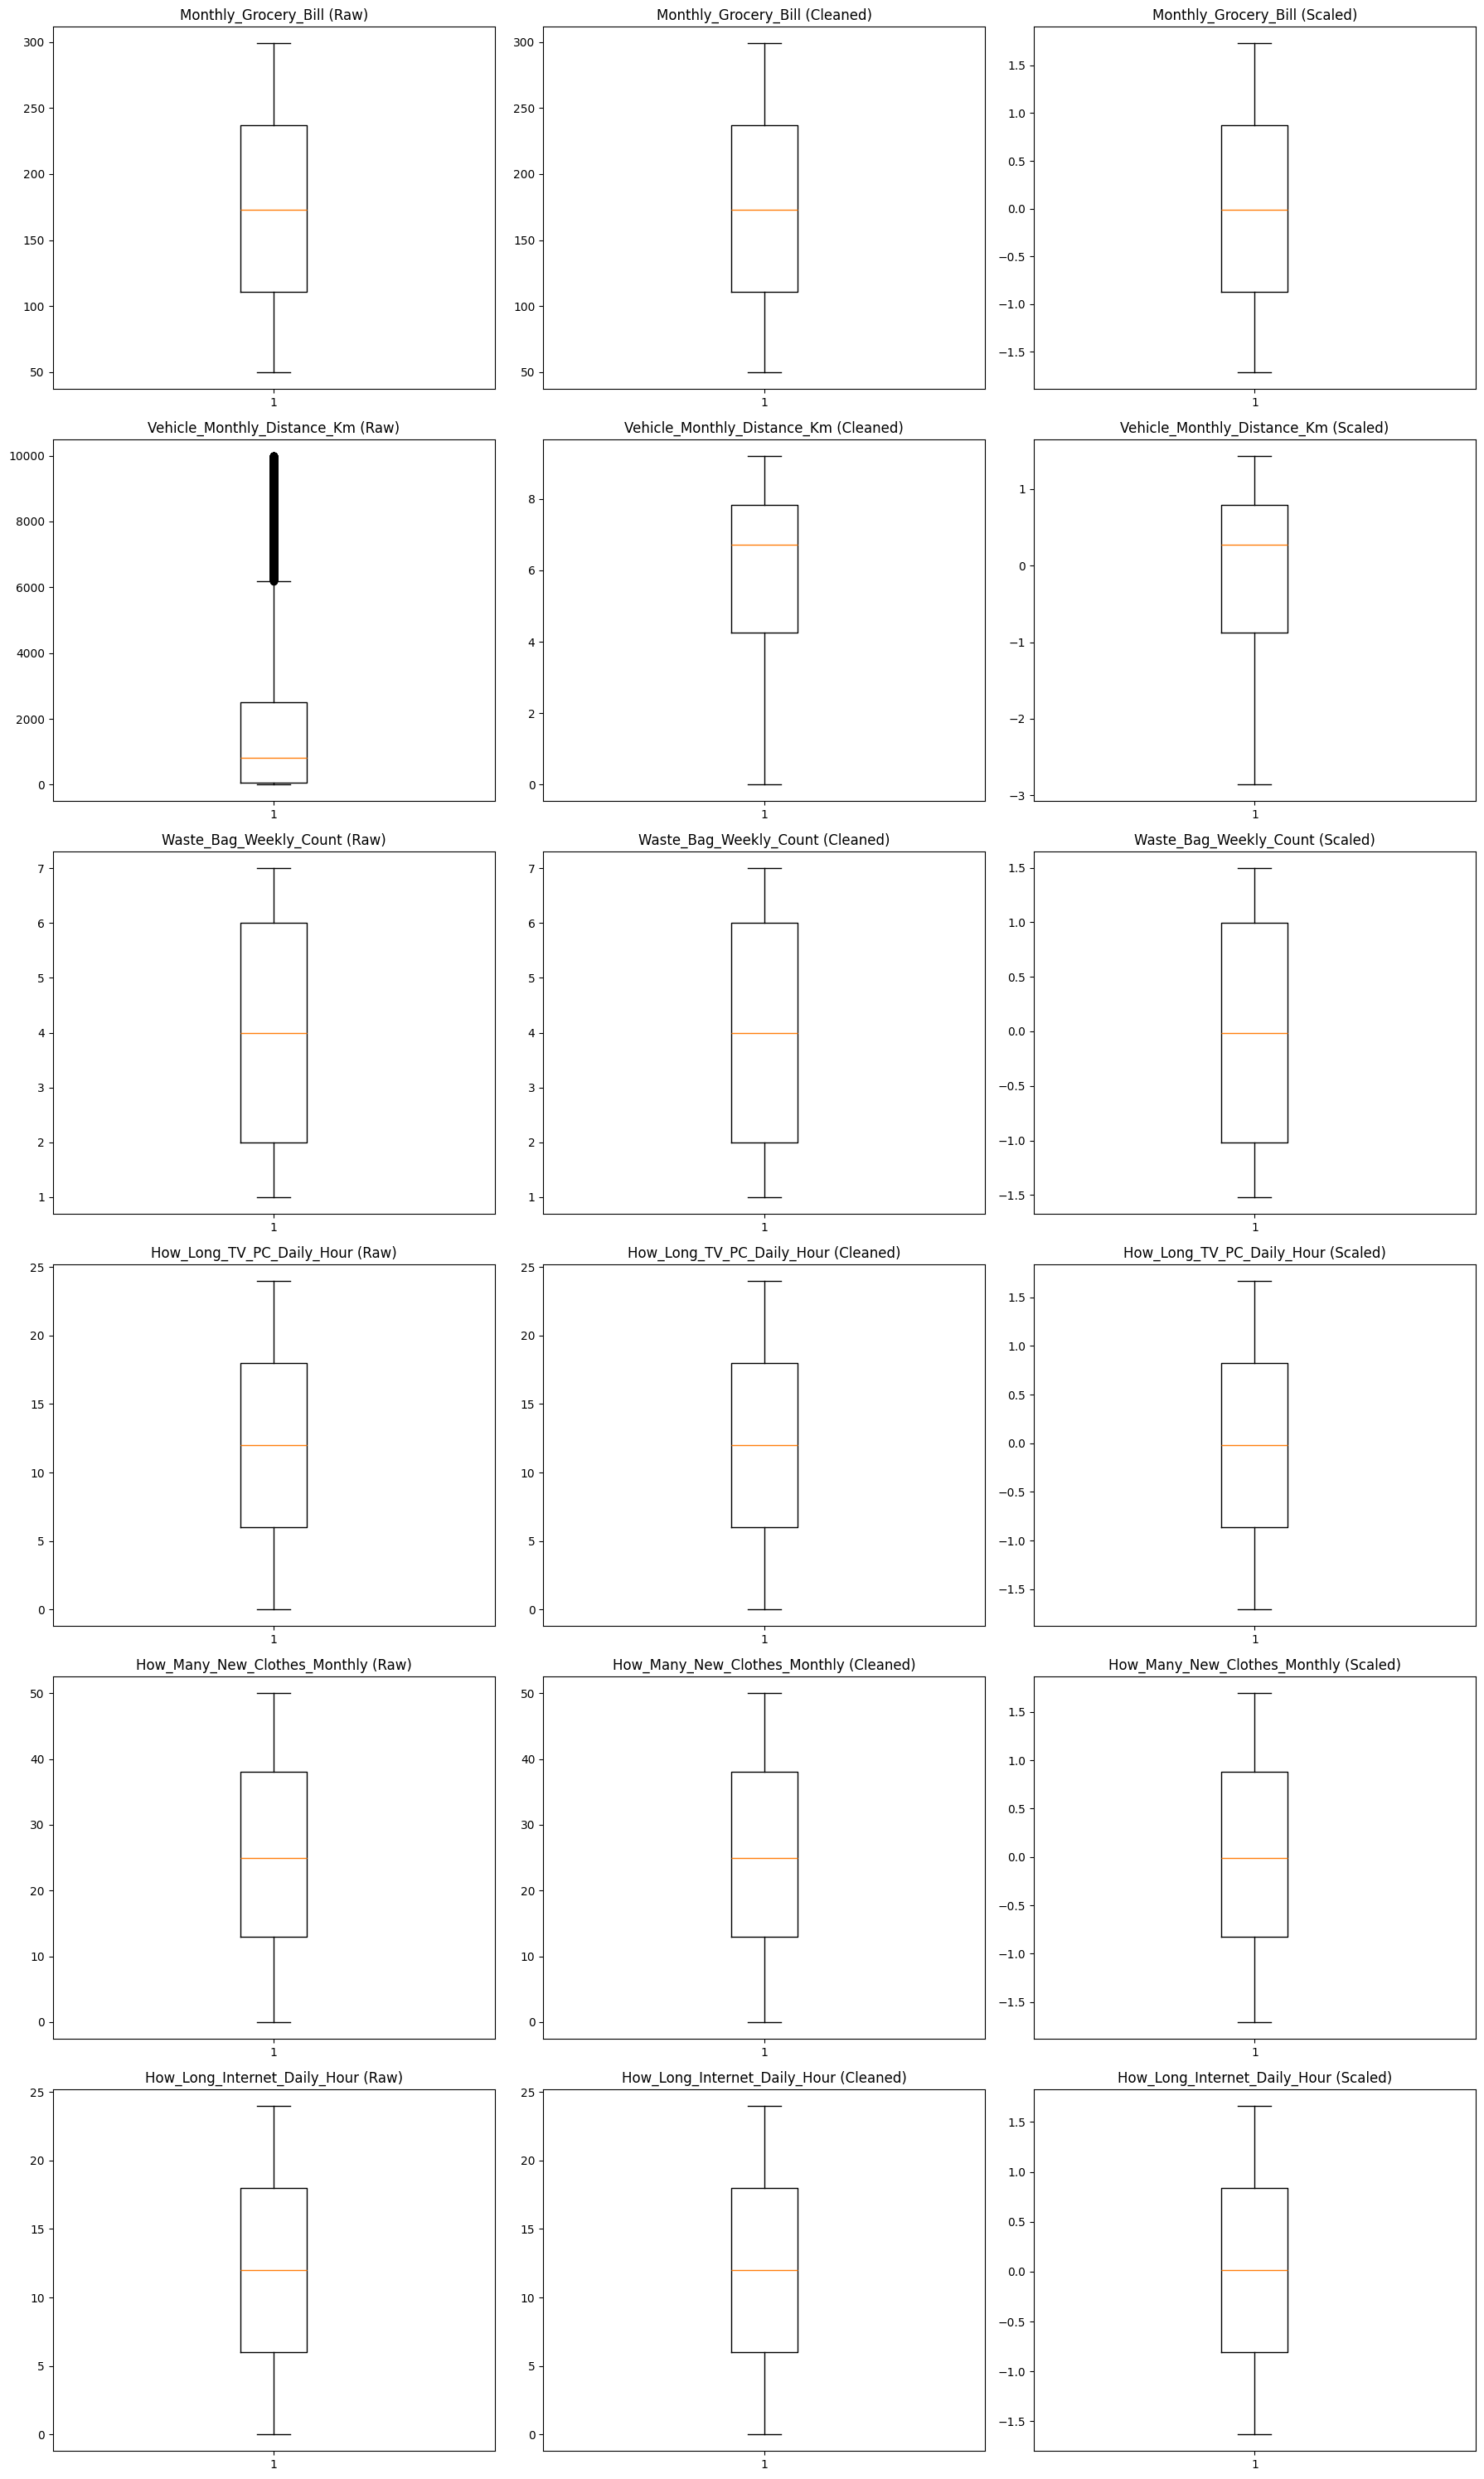

In [23]:
plt.figure(figsize=(18, 5 * len(num_cols)))

for i, col in enumerate(num_cols):

    # RAW
    plt.subplot(len(num_cols), 3, i*3 + 1)
    plt.boxplot(df[col])
    plt.title(f"{col} (Raw)")

    # CLEANED
    plt.subplot(len(num_cols), 3, i*3 + 2)
    plt.boxplot(df_clean[col])
    plt.title(f"{col} (Cleaned)")

    # SCALED
    plt.subplot(len(num_cols), 3, i*3 + 3)
    plt.boxplot(df_scaled[col])
    plt.title(f"{col} (Scaled)")

plt.tight_layout()
plt.show()

**Bivariate and Multivariate Analysis**

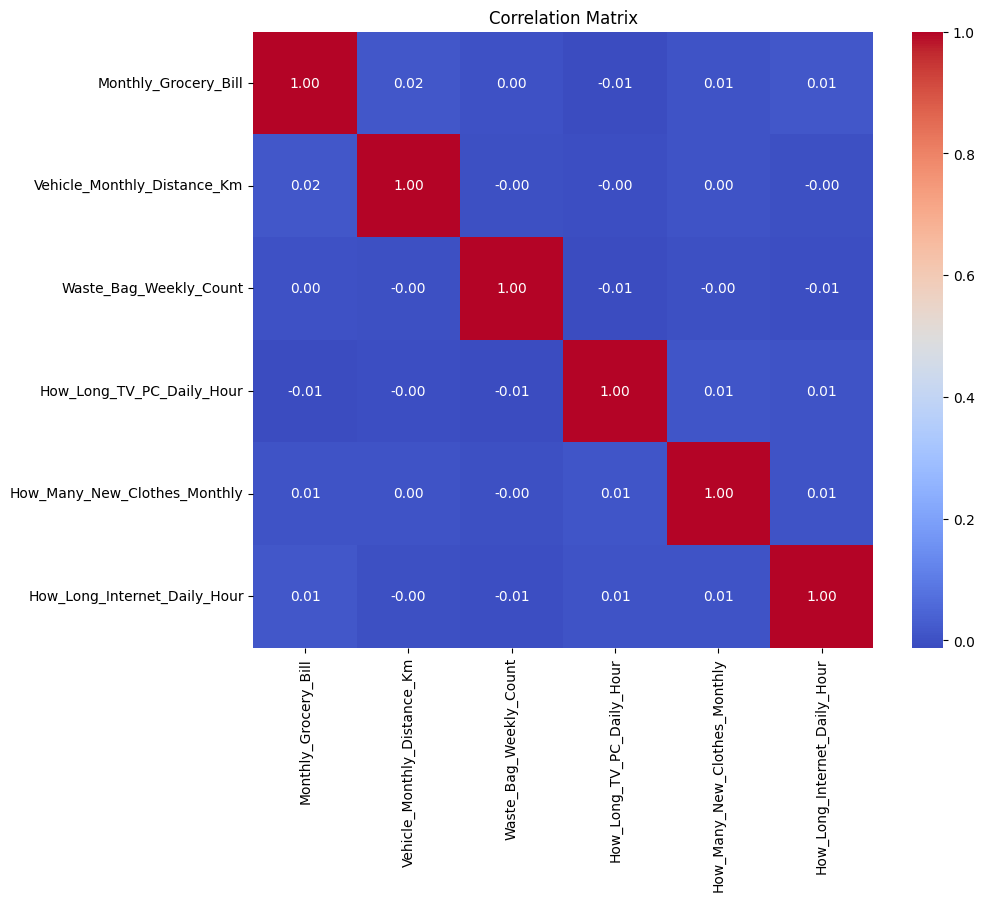

In [24]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

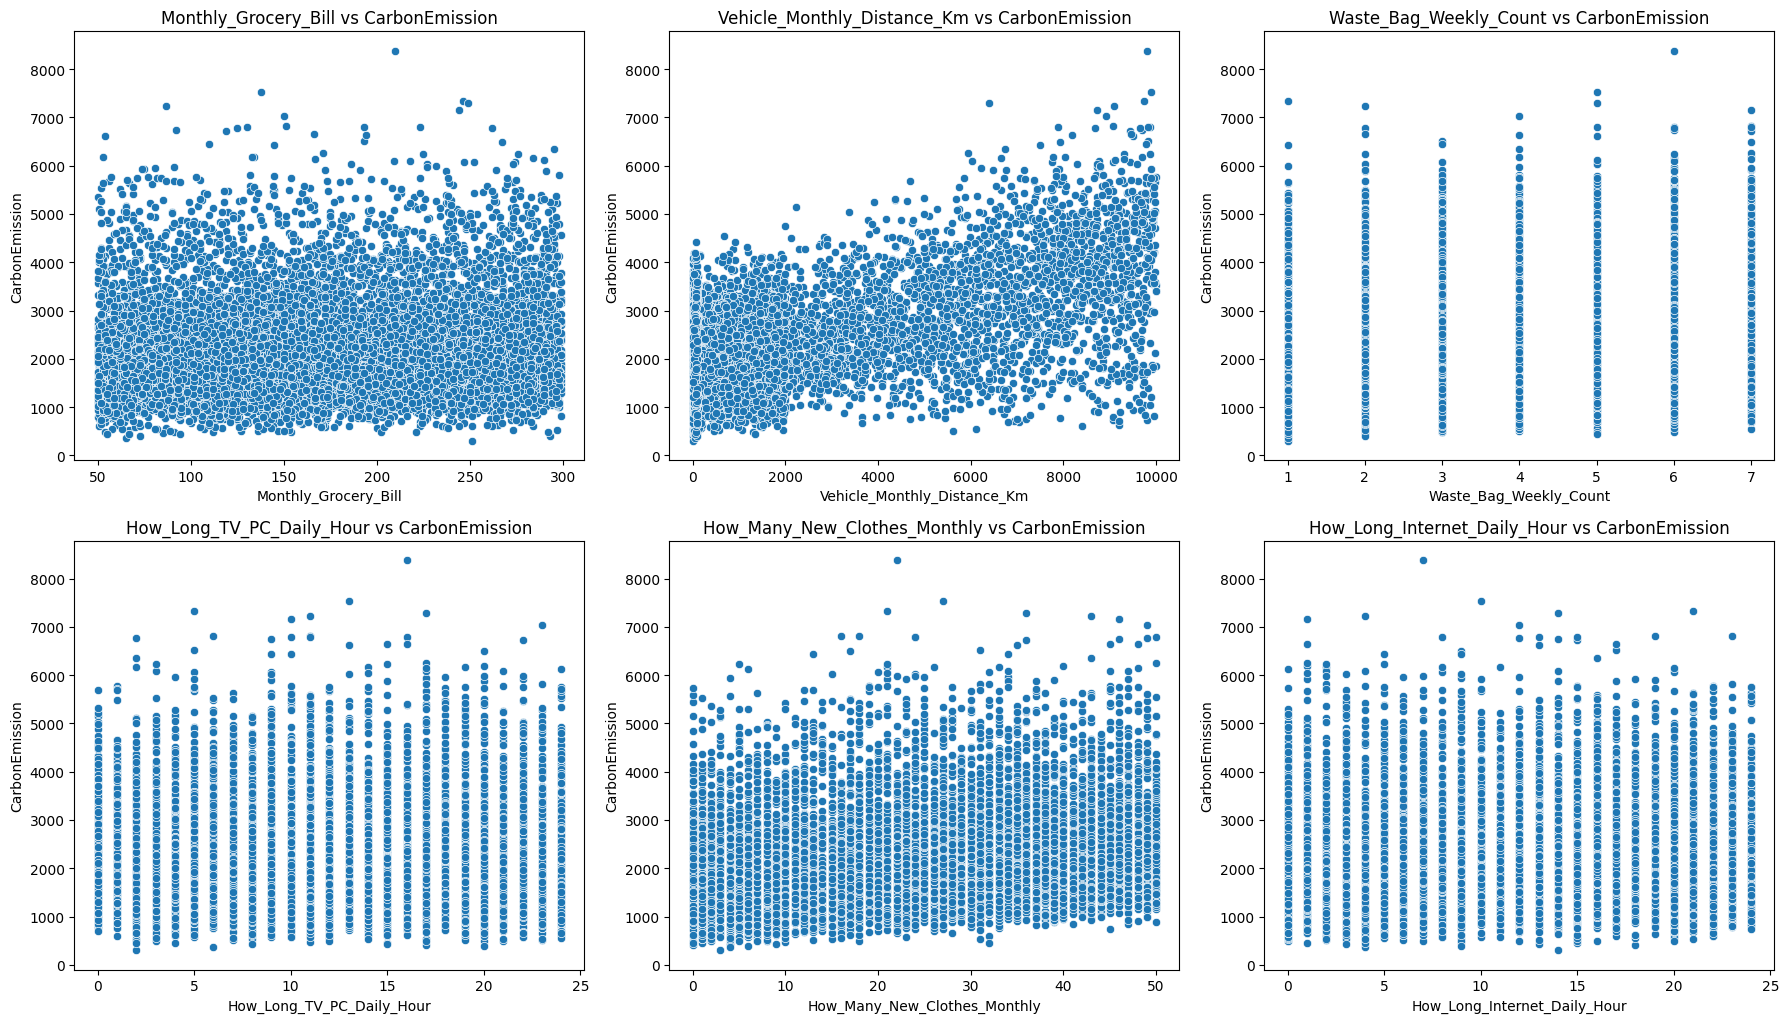

In [25]:
cols = 3
rows = (len(num_cols) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(num_cols, 1):
    if col == 'CarbonEmission':
        continue

    plt.subplot(rows, cols, i)
    sns.scatterplot(x=df[col], y=df['CarbonEmission'])
    plt.title(f"{col} vs CarbonEmission")

plt.tight_layout()
plt.show()

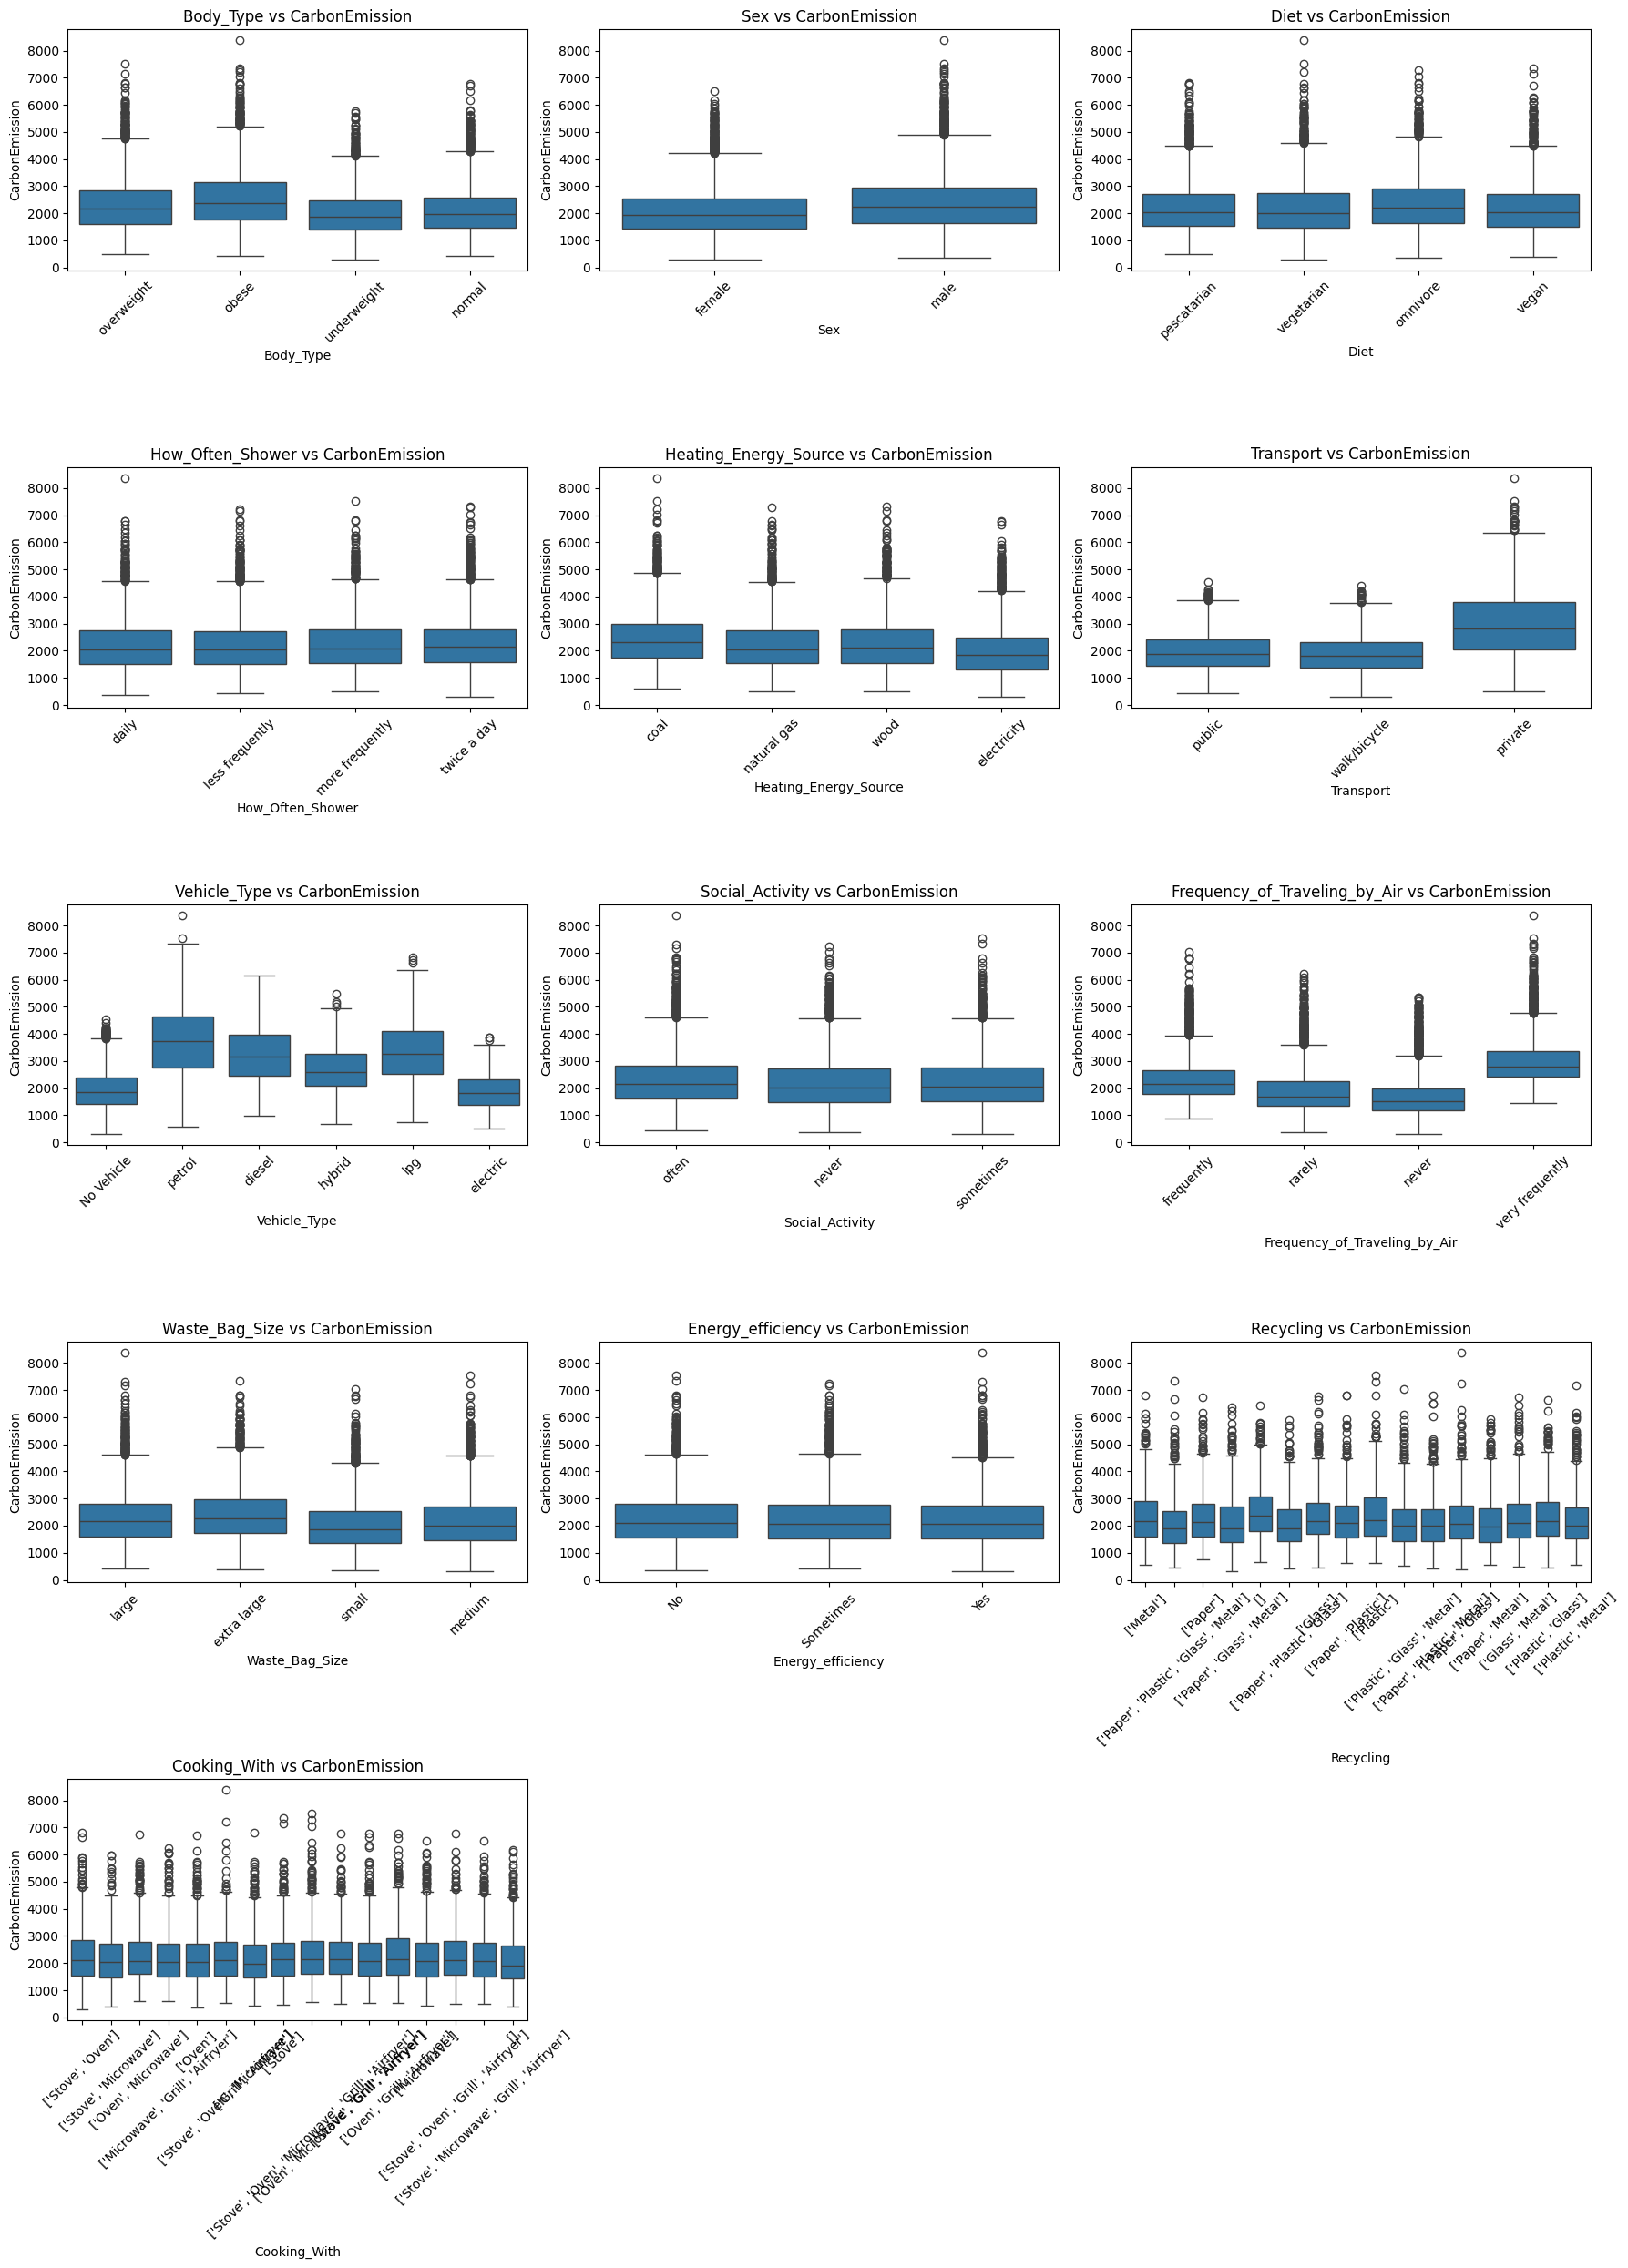

In [26]:
cat_cols = df.select_dtypes(include=['object']).columns

cols = 3
rows = (len(cat_cols) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=col, y='CarbonEmission', data=df)
    plt.title(f"{col} vs CarbonEmission")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

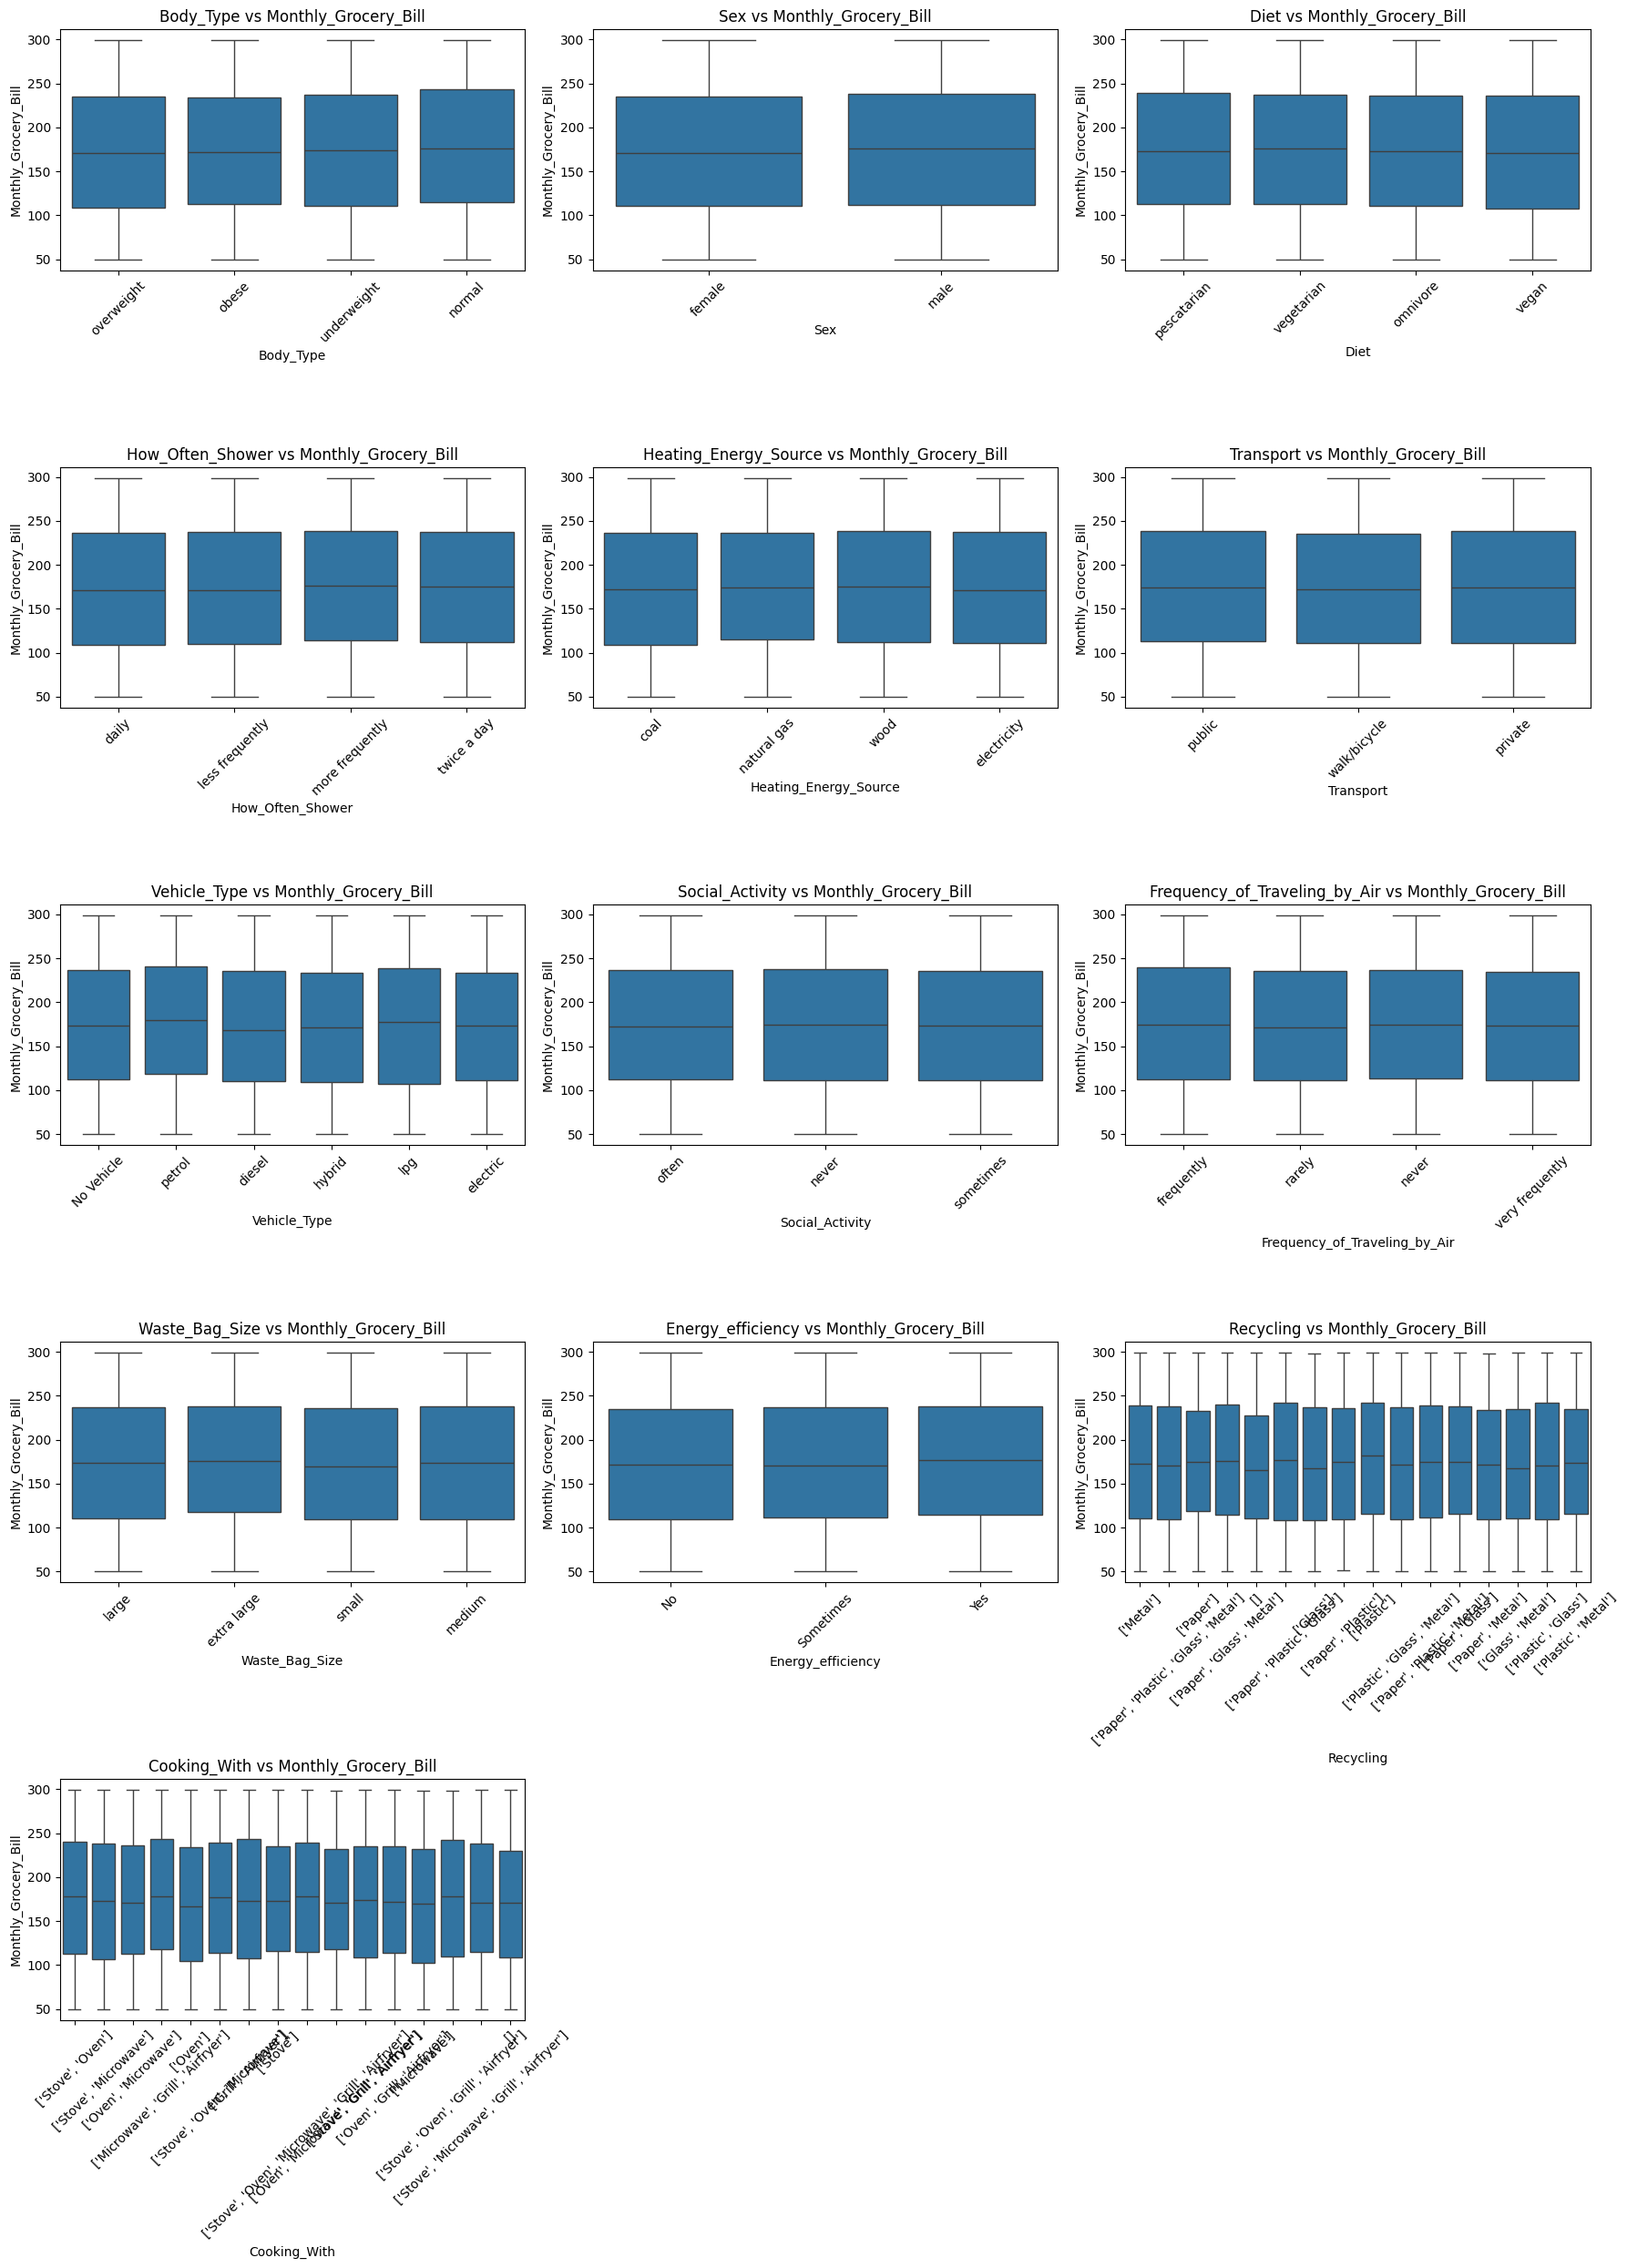

In [27]:
cols = 3
rows = (len(cat_cols) // cols) + 1

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=col, y=df[num_cols[0]], data=df)  # change num_cols[0] as needed
    plt.title(f"{col} vs {num_cols[0]}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

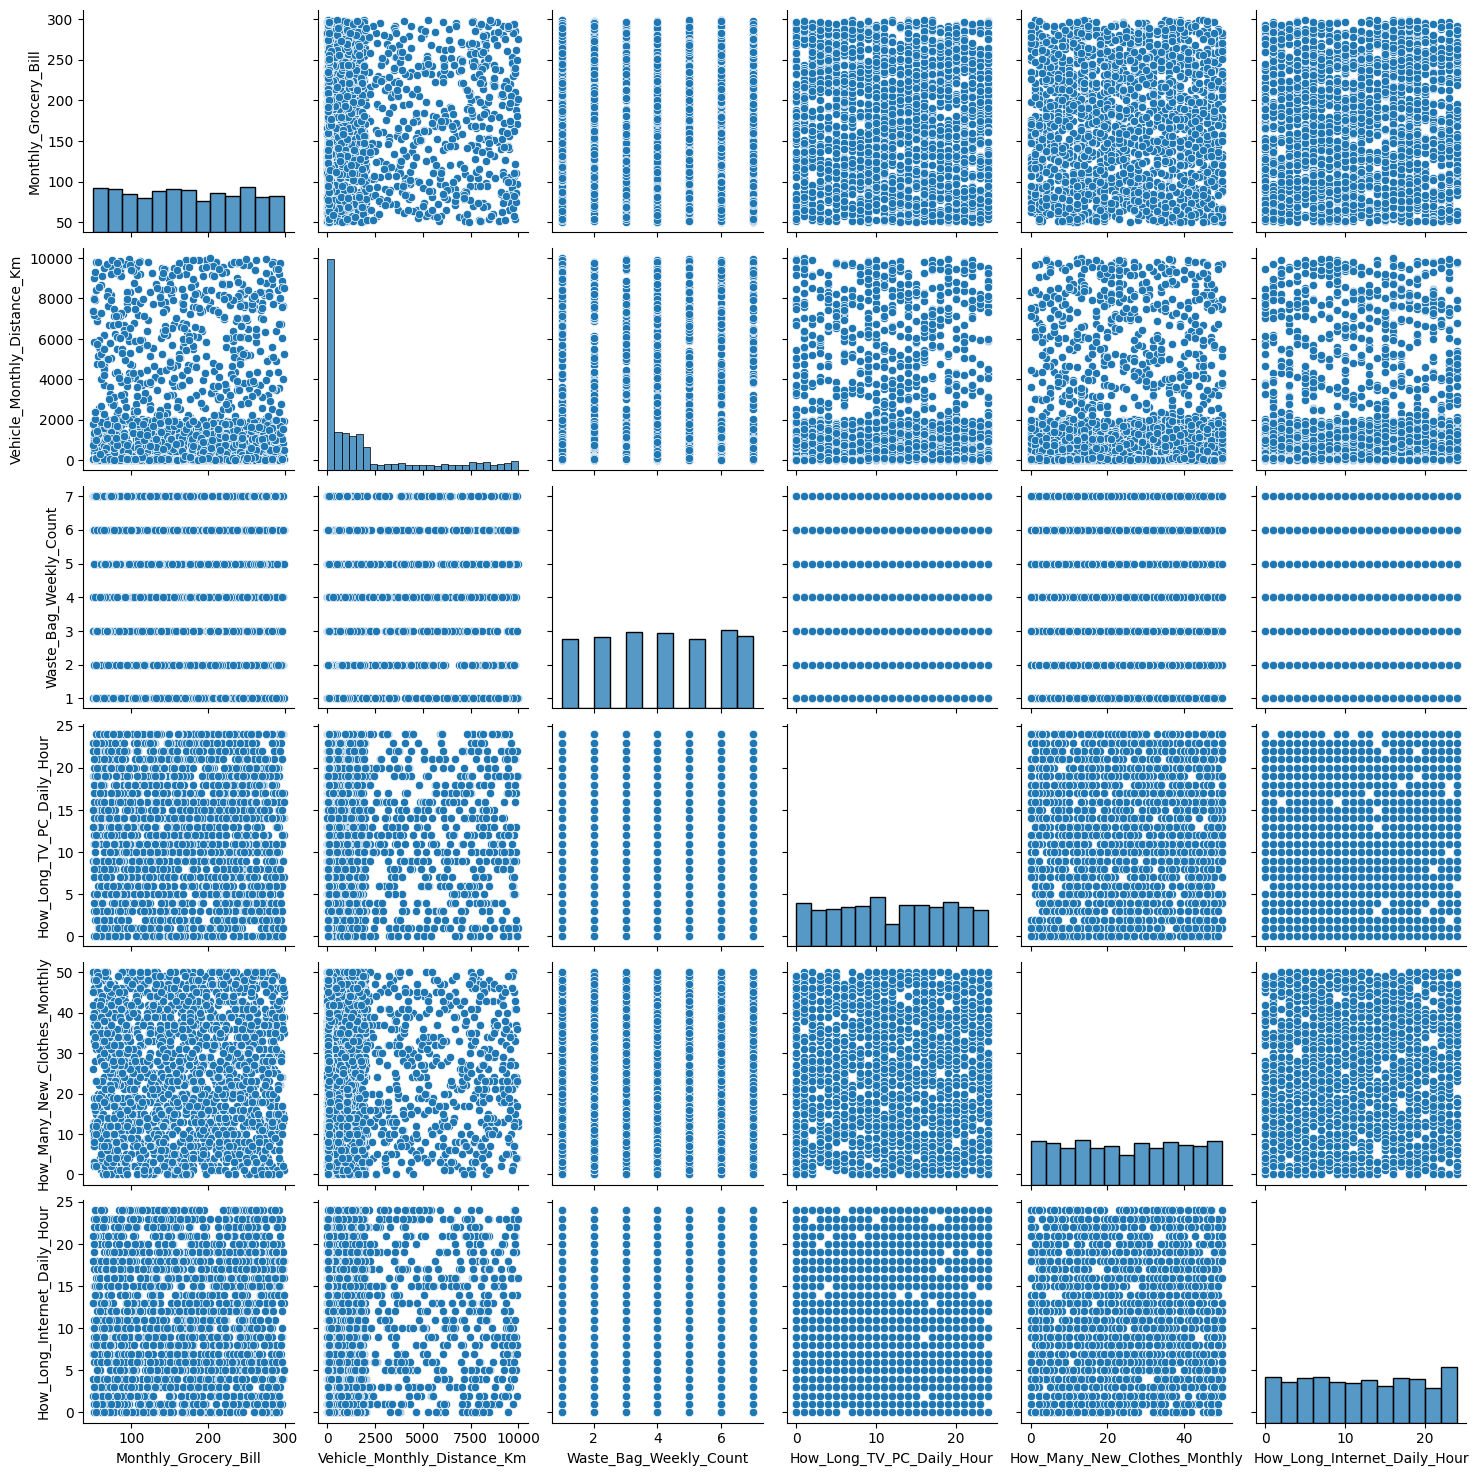

In [28]:
sample_df = df.sample(2000)

sns.pairplot(sample_df[num_cols])
plt.show()

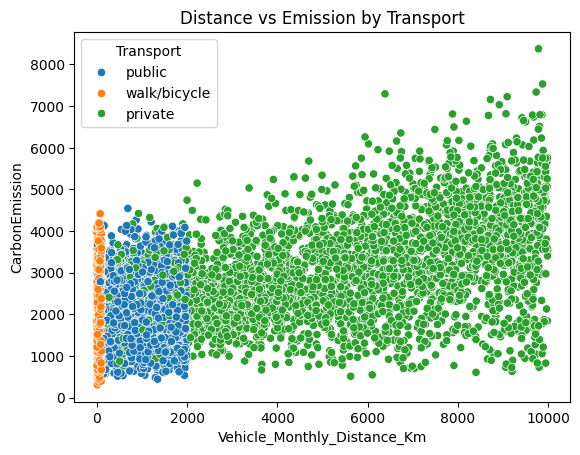

In [29]:
sns.scatterplot(
    x='Vehicle_Monthly_Distance_Km',
    y='CarbonEmission',
    hue='Transport',
    data=df
)
plt.title("Distance vs Emission by Transport")
plt.show()

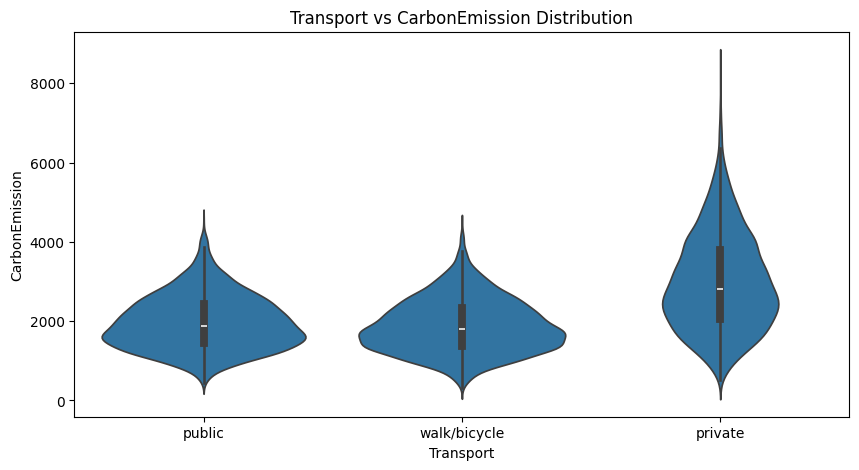

In [30]:
plt.figure(figsize=(10, 5))
sns.violinplot(x='Transport', y='CarbonEmission', data=df)
plt.title("Transport vs CarbonEmission Distribution")
plt.show()

In [31]:


num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('CarbonEmission')  # protect target

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

In [33]:
df[num_cols].describe()

,Monthly_Grocery_Bill,Vehicle_Monthly_Distance_Km,Waste_Bag_Weekly_Count,How_Long_TV_PC_Daily_Hour,How_Many_New_Clothes_Monthly,How_Long_Internet_Daily_Hour
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,173.875200,1777.613225,4.024600,12.139200,25.109000,11.889100
std,72.234018,2200.677650,1.990375,7.106369,14.698725,7.277218
min,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000
50%,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000
75%,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000
max,299.000000,6188.375000,7.000000,24.000000,50.000000,24.000000


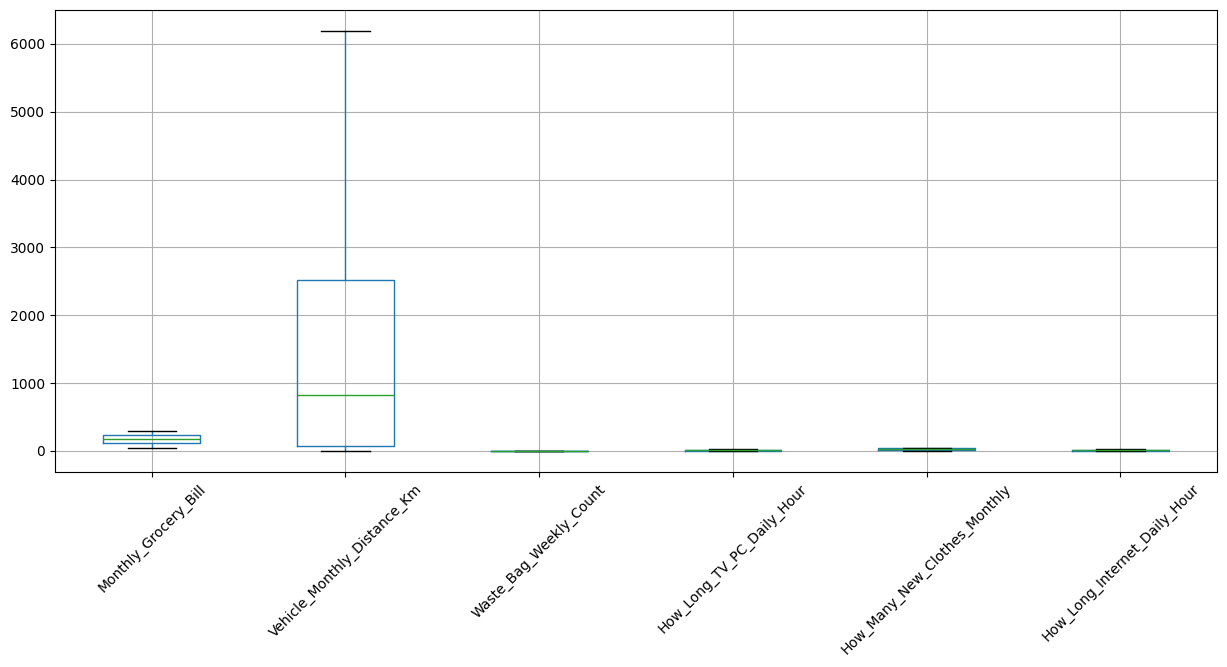

In [34]:
plt.figure(figsize=(15,6))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.show()

In [35]:
df['Vehicle_Monthly_Distance_Km'] = np.log1p(df['Vehicle_Monthly_Distance_Km'])

In [36]:
# df.to_csv('cleaned_data.csv', index=False)

In [37]:
# from google.colab import files
# files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv('cleaned_data.csv')

Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('CarbonEmission', axis=1)
y = df['CarbonEmission']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 19)
X_test : (2000, 19)
y_train: (8000,)
y_test : (2000,)


In [40]:
print(X_train.columns)

Index(['Body_Type', 'Sex', 'Diet', 'How_Often_Shower', 'Heating_Energy_Source',
       'Transport', 'Vehicle_Type', 'Social_Activity', 'Monthly_Grocery_Bill',
       'Frequency_of_Traveling_by_Air', 'Vehicle_Monthly_Distance_Km',
       'Waste_Bag_Size', 'Waste_Bag_Weekly_Count', 'How_Long_TV_PC_Daily_Hour',
       'How_Many_New_Clothes_Monthly', 'How_Long_Internet_Daily_Hour',
       'Energy_efficiency', 'Recycling', 'Cooking_With'],
      dtype='object')


Feature Selection

In [41]:
drop_cols = [
    'Diet',
    'Social_Activity',
    'Monthly_Grocery_Bill',
    'How_Often_Shower'
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [42]:
# Reduce categories (example for Cooking_With)
top_categories = X_train['Cooking_With'].value_counts().nlargest(5).index

X_train['Cooking_With'] = X_train['Cooking_With'].apply(
    lambda x: x if x in top_categories else 'Other'
)

X_test['Cooking_With'] = X_test['Cooking_With'].apply(
    lambda x: x if x in top_categories else 'Other'
)

In [43]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [44]:

corr = X_train.corr()

# Remove highly correlated features (>0.9)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

In [45]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

Vehicle_Monthly_Distance_Km                      0.369844
Frequency_of_Traveling_by_Air_very frequently    0.184962
Vehicle_Type_electric                            0.120709
How_Many_New_Clothes_Monthly                     0.053899
Waste_Bag_Weekly_Count                           0.029079
Sex_male                                         0.025293
Frequency_of_Traveling_by_Air_never              0.024831
Body_Type_obese                                  0.024718
Vehicle_Type_hybrid                              0.024360
Frequency_of_Traveling_by_Air_rarely             0.020995
Vehicle_Type_petrol                              0.020582
Heating_Energy_Source_electricity                0.014336
How_Long_Internet_Daily_Hour                     0.012803
Waste_Bag_Size_small                             0.010926
How_Long_TV_PC_Daily_Hour                        0.010501
dtype: float64


In [46]:
top_features = importances.head(10).index

X_train = X_train[top_features]
X_test = X_test[top_features]

Model Training

In [47]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 310.42997902380955
MSE : 161325.7578809481
RMSE: 401.6537786215239
R2 Score: 0.8448355629235679


In [50]:

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

Vehicle_Monthly_Distance_Km                      0.409786
Frequency_of_Traveling_by_Air_very frequently    0.185175
Vehicle_Type_electric                            0.122279
How_Many_New_Clothes_Monthly                     0.095222
Waste_Bag_Weekly_Count                           0.047381
Body_Type_obese                                  0.030158
Sex_male                                         0.029760
Vehicle_Type_hybrid                              0.029444
Frequency_of_Traveling_by_Air_never              0.027422
Frequency_of_Traveling_by_Air_rarely             0.023374
dtype: float64


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [52]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [53]:
from sklearn.metrics import r2_score

print("New R2:", r2_score(y_test, y_pred))

New R2: 0.8599115950239794


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest (tuned)
y_pred_rf = best_model.predict(X_test)

# Results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest (Tuned)'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

                   Model  R2 Score
0      Linear Regression  0.584941
1          Decision Tree  0.724284
2  Random Forest (Tuned)  0.859912


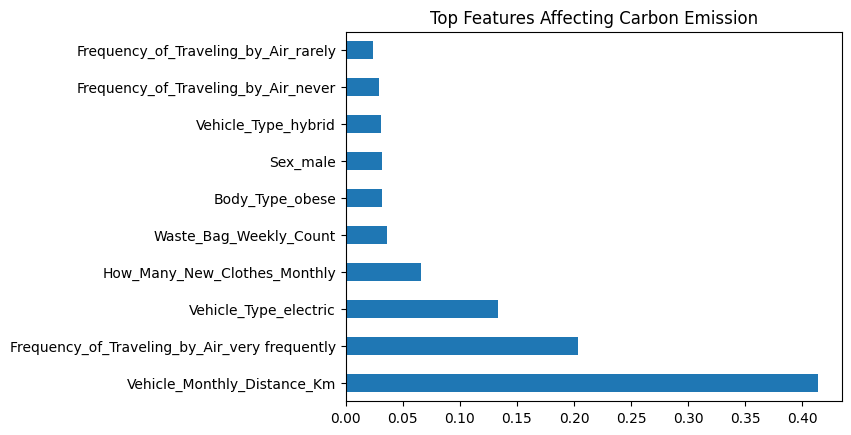

In [60]:

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Carbon Emission")
plt.show()

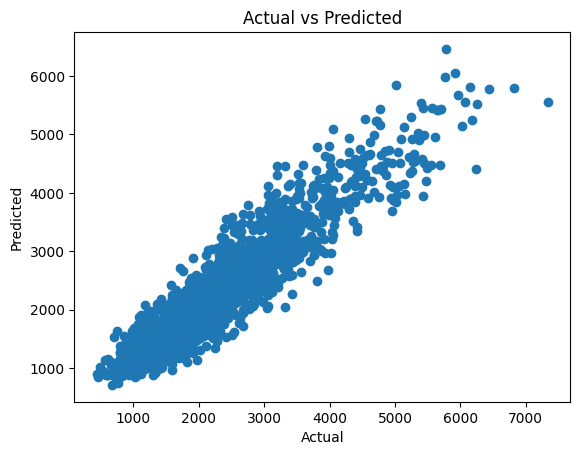

In [61]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()